# Figure List 


This ipython notebook is meant to create all tables and figures from the DeepStateGNN draft based on api-calles from Weights & Bias. Navigate to the sub headings to find the different tables and figures.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

In [2]:
api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /shared/home/cyw5037/.netrc.


In [3]:


from tqdm import tqdm
def get_runs_with_filters(filters):
    api = wandb.Api()
    runs = api.runs("usc-infolab/deepstategnn", filters = filters)
    return runs



def extract_run_data(runs, access_metadata = True):
    summary_list, config_list, name_list = [], [], []

    model_name_list = []
    mask_name_list = []
    mask_iter_list = []
    dataset_list = []
    test_avg_mae_list = []
    test_available_sensors_avg_mae_list = []
    test_dropped_available_sensors_avg_mae_list = []
    test_unavailable_sensors_avg_mae_list = []
    test_dropped_unavailable_sensors_avg_mae_list = []
    test_avg_rmse_list = []
    test_avg_mape_list = []
    val_loss_list = []
    epochs_list = []
    n_context_emb_list = []
    n_context_list = []
    n_hid_list = []
    static_prefilter_mode_list = []
    static_prefilter_leave_out_list = []
    gcn_layers_list = []
    ablation_concat_queries_list = []
    dsn_div_weight_list = []
    dsn_div_margin_list = []
    dropout_list = []
    benchmark_inference_mean_time_list = []
    benchmark_inference_std_time_list = []
    attention_method_list = []

    state_list = []
    tag_list = []
    gpu_type_list = [] 
    train_time_per_epoch_list = []
    val_time_list = []



    for run in tqdm(runs):
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files
        summary_list.append(run.summary._json_dict)
        
        # .config contains the hyperparameters.
        #  We remove special values that start with _.
        config_list.append(
            {k: v for k,v in run.config.items()
            if not k.startswith('_')})

        # .name is the human-readable name of the run.
        name_list.append(run.name)

        model_name_list.append(run.config.get("model_name"))
        mask_name_list.append(run.config.get("mask_name"))
        mask_iter_list.append(run.config.get("mask_iter"))
        dataset_list.append(run.config.get("dataset"))
        static_prefilter_mode_list.append(run.config.get("static_prefilter_mode", None))
        static_prefilter_leave_out_list.append(run.config.get("ablation_static_dsn_leave_out", None))
        n_context_emb_list.append(run.config.get("n_context_emb"))
        n_context_list.append(run.config.get("n_context"))
        n_hid_list.append(run.config.get("n_hid"))
        gcn_layers_list.append(run.config.get("gcn_layers"))
        attention_method_list.append(run.config.get("attention_method"))
        ablation_concat_queries_list.append(run.config.get("adding_query_to_dsn"))
        dsn_div_weight_list.append(run.config.get("dsn_div_weight"))
        dsn_div_margin_list.append(run.config.get("dsn_div_margin"))
        dropout_list.append(run.config.get("dropout"))

        if access_metadata:
            gpu_type_list.append(run.metadata.get("gpu") if run.metadata is not None else None)
        else:
            gpu_type_list.append(None)
        test_avg_mae_list.append(run.summary.get("test/avg_mae"))
        test_avg_rmse_list.append(run.summary.get("test/avg_rmse"))
        test_avg_mape_list.append(run.summary.get("test/avg_mape"))
        
        train_time_per_epoch_list.append(run.summary.get("train/time_per_epoch"))
        benchmark_inference_mean_time_list.append(run.summary.get("benchmark/inference_time_mean"))
        benchmark_inference_std_time_list.append(run.summary.get("benchmark/inference_time_std"))
        val_time_list.append(run.summary.get("val/time"))
        epochs_list.append(run.summary.get("epoch", None))
        state_list.append(run.state)
        tag_list.append(run.tags)


        if "test/available_sensors/avg_mae" in run.summary:
            test_available_sensors_avg_mae_list.append(run.summary.get("test/available_sensors/avg_mae"))
            test_dropped_available_sensors_avg_mae_list.append(run.summary.get("test_dropped/available_sensors/avg_mae"))
        else:
            test_available_sensors_avg_mae_list.append(None)
            test_dropped_available_sensors_avg_mae_list.append(None)
        if "test/unavailable_sensors/avg_mae" in run.summary:
            test_unavailable_sensors_avg_mae_list.append(run.summary.get("test/unavailable_sensors/avg_mae"))
            test_dropped_unavailable_sensors_avg_mae_list.append(run.summary.get("test_dropped/unavailable_sensors/avg_mae"))
        else:
            test_unavailable_sensors_avg_mae_list.append(None)
            test_dropped_unavailable_sensors_avg_mae_list.append(None)
        if 'val/loss' in run.history_keys['keys'] and False:

            df = run.history(samples=100, keys=["val/loss"], pandas=True, stream="default")

            val_loss_list.append(df['val/loss'].min())

        else:
            val_loss_list.append(None)

    runs_df = pd.DataFrame({
        "summary": summary_list,
        "config": config_list,
        "name": name_list
        })
    
    runs = pd.DataFrame(
        {
            "model_name": model_name_list,
            "mask_name": mask_name_list,
            "mask_iter": mask_iter_list,
            "dataset": dataset_list,
            "gpu_type": gpu_type_list,
            "n_context_emb": n_context_emb_list,
            "n_hid": n_hid_list,
            "static_prefilter_mode": static_prefilter_mode_list,
            "static_prefilter_leave_out": static_prefilter_leave_out_list,
            "gcn_layers": gcn_layers_list,
            "ablation_concat_queries": ablation_concat_queries_list,
            "dsn_div_weight": dsn_div_weight_list,
            "dsn_div_margin": dsn_div_margin_list,
            "attention_method": attention_method_list,  
            "dropout": dropout_list,
            "n_context": n_context_list,    
            "test_avg_mae": test_avg_mae_list,
            "test_available_sensors_avg_mae": test_available_sensors_avg_mae_list,
            "test_dropped_available_sensors_avg_mae": test_dropped_available_sensors_avg_mae_list,
            "test_unavailable_sensors_avg_mae": test_unavailable_sensors_avg_mae_list,
            "test_dropped_unavailable_sensors_avg_mae": test_dropped_unavailable_sensors_avg_mae_list,
            "train_time_per_epoch": train_time_per_epoch_list,
            "benchmark_inference_mean_time": benchmark_inference_mean_time_list,
            "benchmark_inference_std_time": benchmark_inference_std_time_list,
            "test_avg_mape": test_avg_mape_list,
            "test_avg_rmse": test_avg_rmse_list,
            "name": name_list, 
            "epochs": epochs_list,
            "state": state_list,
            "tags": tag_list,
            "val_loss": val_loss_list,
            "val_time": val_time_list
        }
    )
    # check if the tag withMD is set in the list of tags
    runs["withMD"] = runs["tags"].apply(lambda x: "withMD" in x)
    runs["benchmark_GBA"] = runs["tags"].apply(lambda x: "benchmark_GBA" in x)
    runs["benchmark_CA"] = runs["tags"].apply(lambda x: "benchmark_CA" in x)
    runs["train_mask"] = runs["tags"].apply(lambda x: "train_mask" in x)


    # runs= runs[(runs["state"] == "finished") & (runs["withMD"] | runs["benchmark_GBA"] ) ]
    runs['withMD'] = runs['withMD'].astype(str)
    runs.loc[runs['mask_name'].isna(), 'mask_name'] = 'no_mask'
    
    return runs

In [4]:
import seaborn as sns
global_color_list = ['COMLP', 'AGCRN', 'ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'OPCR', 'SPIN', 'STGode', 'STGCN', 'PDFormer', 'DeepStateGNN']

global_ordering = ['DCRNN', 'AGCRN', 'STGCN', 'ASTGCN', 'GWNET', 'GMAN', 'PDFormer', 'D2STGNN', 'STGode', 'BigST', 'GSNet', 'SPIN', 'OPCR', 'COMLP','DeepStateGNN']

global_color_dict = dict(zip(global_ordering, sns.color_palette("tab20").as_hex()[:len(global_ordering)]))


global_color_dict['DeepStateGNN'] = 'tab:blue'

global_category_dict = {
    'AGCRN':  'sensor-level',
    'ASTGCN': 'sensor-level',
    'STGCN': 'sensor-level',
    'GWNET': 'sensor-level',
    'GMAN': 'sensor-level',
    'PDFormer': 'sensor-level',
    'DCRNN': 'sensor-level',
    'D2STGNN': 'sensor-level',
    'STGode': 'sensor-level',
    'BigST': 'scalable sensor-level',
    'GSNet': 'scalable sensor-level',
    'SPIN': 'sparse data reconstruction',
    'OPCR': 'sparse data reconstruction',
    'DeepStateGNN': 'cool',
    'DSGNN': 'cool'
}

# create a dataframe from the global category dict
global_category_df = pd.DataFrame.from_dict(global_category_dict, orient='index', columns=['category'])
global_category_df.index.name = 'model_name'

## Paper Figures


## Accuracy as Latex table


In [5]:
md_runs_with_point_missing_from_CA_benchmark_without_outdated = get_runs_with_filters(
    {'$and': 
        [
            {
                "$or":[
                    {'$and':
                        [
                            {'tags': {"$in": ["withMD"]}}, 
                            {'tags': {"$ne": "outdated"}}
                            ]
                        },
                    {'$and':
                        [
                            {'tags': {"$in": ["benchmark_CA"]}},
                            {'config.dataset': 'SD'}
                        ]
                    }
                ]
            }
            , 
            {'state': 'finished'}, 
            {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}
         ]}
    )


In [6]:
# runs_withMD = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["withMD"]}}, {'tags': {"$ne": "outdated"}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)
runs_withMD = extract_run_data(md_runs_with_point_missing_from_CA_benchmark_without_outdated, access_metadata = False)
runs_inference_time = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["inference_time_benchmark"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)


100%|██████████| 160/160 [00:39<00:00,  4.00it/s]


In [7]:
category_dict = {
    'sensor-level': 'o',
    'scalable sensor-level': 'X',
    'sparse data reconstruction': 's',
    'cool': 'D'
}

In [8]:
import numpy as np
memory_consumption = {
    'AGCRN':    [(10.42, 64), (34.81, 64), (np.nan, np.nan)],
    'ASTGCN':   [(12.45, 64), (75.75, 64), (58.33, 4)],
    'D2STGNN':  [(77.39, 64), (79.44, 8),  (np.nan, np.nan)],
    'DCRNN':    [(17.23, 64), (47.54, 64), (53.16, 16)],
    'GMAN':     [(67.63, 16), (41.98, 1),  (np.nan, np.nan)],
    'PDFormer': [(21.01, 16), (41.74, 4),  (np.nan, np.nan)],
    'STGCN':    [(4.97, 64),  (11.09, 64), (52.04, 64)],
    'GWNET':    [(9.81, 64),  (42.08, 64), (51.12, 32)],
    'STGode':   [(22.35, 64), (62.67, 64), (np.nan, np.nan)],
    'BigST':    [(10.99, 64), (27.87, 64), (52.35, 32)],
    'GSNet':    [(3.22, 64),  (7.31, 64),  (54.63, 64)],
    'OPCR':     [(17.20, 64), (75.49, 64), (72.22, 16)],
    'SPIN':     [(65.92, 16), (60.93, 4),  (125, 2)],
    'DSGNN':    [(3.36, 64),  (9.9, 64),   (56.13, 64)],
}


df_gpu_mem = pd.DataFrame.from_dict(memory_consumption, orient='index', columns=['SD', 'GBA', 'CA'])
df_gpu_mem['SD_mem'] = df_gpu_mem['SD'].apply(lambda x: x[0])
df_gpu_mem['GBA_mem'] = df_gpu_mem['GBA'].apply(lambda x: x[0])
df_gpu_mem['CA_mem'] = df_gpu_mem['CA'].apply(lambda x: x[0])
df_gpu_mem['SD_batch'] = df_gpu_mem['SD'].apply(lambda x: x[1])
df_gpu_mem['GBA_batch'] = df_gpu_mem['GBA'].apply(lambda x: x[1])
df_gpu_mem['CA_batch'] = df_gpu_mem['CA'].apply(lambda x: x[1])
df_gpu_mem = df_gpu_mem.reset_index().rename(columns={'index': 'Baseline'})

df_gpu_mem['SD_mem_per_sample'] = df_gpu_mem['SD_mem'] / df_gpu_mem['SD_batch']
df_gpu_mem['GBA_mem_per_sample'] = df_gpu_mem['GBA_mem'] / df_gpu_mem['GBA_batch']
df_gpu_mem['CA_mem_per_sample'] = df_gpu_mem['CA_mem'] / df_gpu_mem['CA_batch']

df_gpu_mem

,Baseline,SD,GBA,CA,SD_mem,GBA_mem,CA_mem,SD_batch,GBA_batch,CA_batch,SD_mem_per_sample,GBA_mem_per_sample,CA_mem_per_sample
0,AGCRN,"(10.42, 64)","(34.81, 64)","(nan, nan)",10.42,34.81,NaN,64,64,NaN,0.162812,0.543906,NaN
1,ASTGCN,"(12.45, 64)","(75.75, 64)","(58.33, 4)",12.45,75.75,58.33,64,64,4.0,0.194531,1.183594,14.582500
2,D2STGNN,"(77.39, 64)","(79.44, 8)","(nan, nan)",77.39,79.44,NaN,64,8,NaN,1.209219,9.930000,NaN
3,DCRNN,"(17.23, 64)","(47.54, 64)","(53.16, 16)",17.23,47.54,53.16,64,64,16.0,0.269219,0.742812,3.322500
4,GMAN,"(67.63, 16)","(41.98, 1)","(nan, nan)",67.63,41.98,NaN,16,1,NaN,4.226875,41.980000,NaN
5,PDFormer,"(21.01, 16)","(41.74, 4)","(nan, nan)",21.01,41.74,NaN,16,4,NaN,1.313125,10.435000,NaN
6,STGCN,"(4.97, 64)","(11.09, 64)","(52.04, 64)",4.97,11.09,52.04,64,64,64.0,0.077656,0.173281,0.813125
7,GWNET,"(9.81, 64)","(42.08, 64)","(51.12, 32)",9.81,42.08,51.12,64,64,32.0,0.153281,0.657500,1.597500
8,STGode,"(22.35, 64)","(62.67, 64)","(nan, nan)",22.35,62.67,NaN,64,64,NaN,0.349219,0.979219,NaN
9,BigST,"(10.99, 64)","(27.87, 64)","(52.35, 32)",10.99,27.87,52.35,64,64,32.0,0.171719,0.435469,1.635938


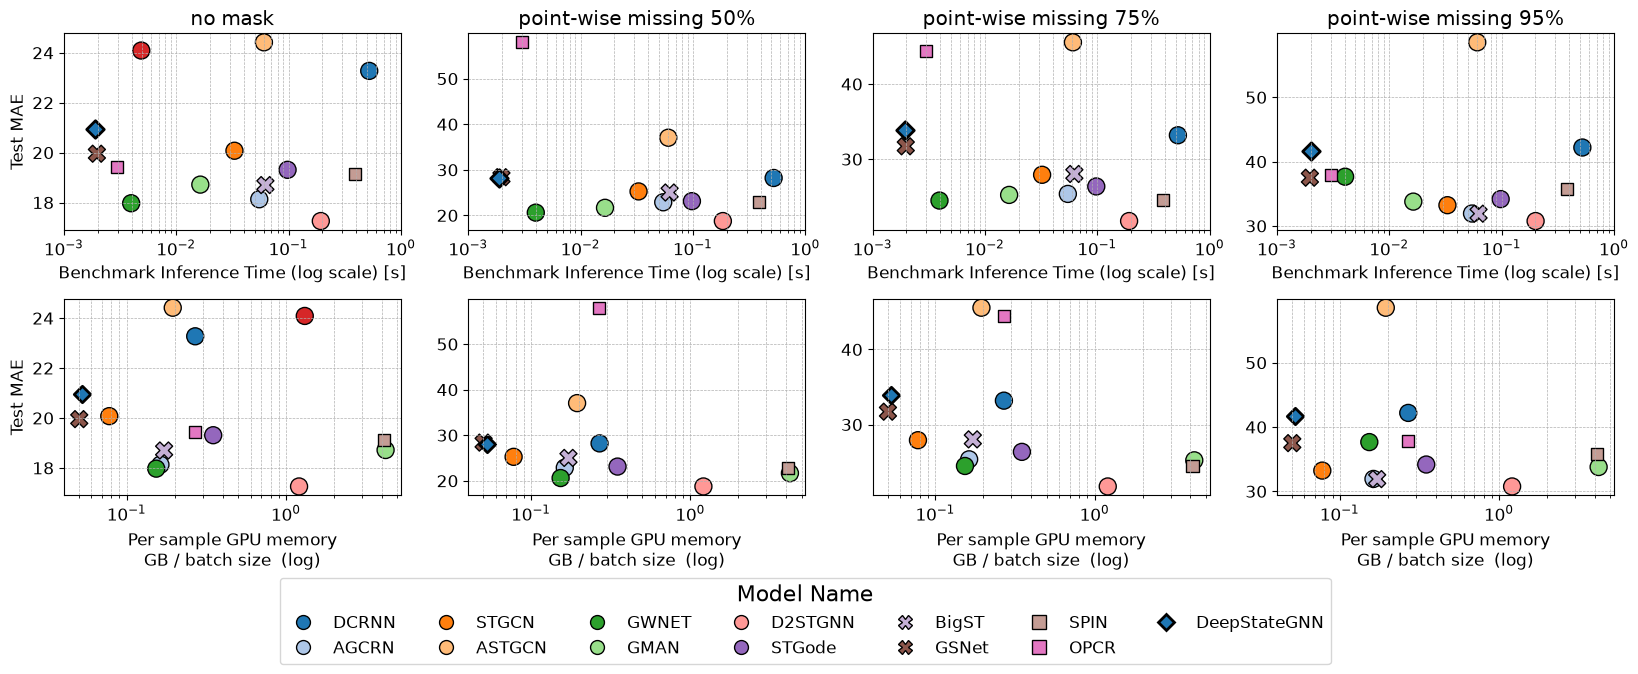

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
runs_inference_time = runs_inference_time.groupby(['mask_name', 'model_name']).mean(True).loc[:, ['benchmark_inference_mean_time', 'benchmark_inference_std_time']] 
grouped_sd_runs = runs_withMD.groupby(['mask_name', 'model_name']).mean(True).loc[:, ['test_avg_mae']] 
grouped_sd_runs = grouped_sd_runs.join(global_category_df, on='model_name', how='left')

joined_metrics = grouped_sd_runs.join(runs_inference_time, on=['mask_name', 'model_name'])

df = df_gpu_mem #pd.read_csv('model_parameters.csv')

# astgcn_org_gba = int(df.loc[df['Baseline'] == 'ASTGCN', 'GBA'].values[0])
# df.loc[df['Baseline'] == 'ASTGCN', 'GBA'] = 4_500_000

joined_metrics = joined_metrics.reset_index().set_index('model_name').join(df.set_index('Baseline').loc[:, ['SD_mem_per_sample']].rename(columns={'SD_mem_per_sample': 'model_paramters_sd'}), on='model_name').reset_index().set_index(['mask_name', 'model_name'])

mask_bla = (~ pd.isna(joined_metrics)).all(axis=1).reset_index().groupby('model_name').all().reset_index()
valid_models = mask_bla[mask_bla.iloc[:, 2]].model_name
# valid_models = valid_models[~valid_models.str.contains('OPCR')]
joined_metrics = joined_metrics[joined_metrics.index.get_level_values('model_name').isin(valid_models)]

joined_metrics = joined_metrics.rename(index={'DSGNN': 'DeepStateGNN'})

## set fontsize to 12
plt.rcParams.update({'font.size': 12})

import matplotlib.pyplot as plt
import seaborn as sns

mask_dictionary = {
    'no_mask': 'no mask',
    'point_missing_050': 'point-wise missing 50%',
    'point_missing_075': 'point-wise missing 75%',
    'point_missing_095': 'point-wise missing 95%',
    'tr_drop_025': 'unseen-sensor 25%',
    'tr_drop_050': 'unseen-sensor 50%',
    'tr_drop_075': 'unseen-sensor 75%',
}


fig = plt.figure(figsize=(20, 6))

mask_i = 0
for mask in joined_metrics.index.get_level_values('mask_name').unique():
    mask_data = joined_metrics.loc[mask].reset_index()
    mask_data = mask_data[mask_data.model_name != 'DeepStateGNN']
    # plt.errorbar(mask_data['benchmark_inference_mean_time'], mask_data['test_avg_mae'], yerr=mask_data['benchmark_inference_std_time'], fmt='o', label=mask)
    ax = fig.add_subplot(2, 4, mask_i + 1)
    
    sns.scatterplot(data=mask_data, x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax, legend = False, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=80, ax = ax, legend = False, edgecolor='black',marker='D', linewidth=2)
    # if mask_i == 3:
    #     sns.move_legend(ax, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
    ax.set_title(f'{mask_dictionary[mask]}')
    plt.xscale('log')
    ax.grid(True, which="both", ls="--", linewidth=0.5)
    
    ax.set_xlabel('Benchmark Inference Time (log scale) [s]')
    
    if mask_i == 0:
        ax.set_ylabel('Test MAE')
    else: 
        ax.set_ylabel(None)
        
    ax.set_xlim(10**-3, 1)
    # ax.set_ylim(ax.get_ylim()[0], 45)

    
    
    ax_model_para = fig.add_subplot(2, 4, mask_i + 1 + 4)
    
    ax_model_para.grid(True, which="both", ls="--", linewidth=0.5)
    sns.scatterplot(data=mask_data, x='model_paramters_sd', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax_model_para, legend = mask_i == 3, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='model_paramters_sd', y='test_avg_mae', hue='model_name', s=70, ax = ax_model_para, legend = mask_i == 3, edgecolor='black',marker='D', linewidth=2)
    
    if mask_i == 3:
        # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
        handles, labels = ax_model_para.get_legend_handles_labels()
        label_index = labels.index('category')
        
        # change the shape of the handles to squares
        for i in range(1, label_index):
            handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
            handles[i].set_markersize(10)
        
        plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(-1.4, -.9), loc='lower center', ncol = 7, title_fontsize=16)
    ax_model_para.set_title(None)
    plt.xscale('log')
    
    # ax_model_para.set_xlabel('Trainable Model Parameters (log scale)')
    ax_model_para.set_xlabel('Per sample GPU memory\nGB / batch size  (log)')
    if mask_i == 0:
        ax_model_para.set_ylabel('Test MAE')#
    else: 
        ax_model_para.set_ylabel(None)

    # ax_model_para.set_xlim(10**5, 10**7)
    mask_i += 1
    
plt.subplots_adjust(hspace=.35)

    
    
# plt.tight_layout()
plt.savefig('img/inference_time_vs_mae.png', dpi=300, bbox_inches='tight')

In [10]:
runs_benchmark_CA = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["benchmark_CA"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None, 'point_missing_075', 'tr_drop_050']}}]}), access_metadata = False)

100%|██████████| 145/145 [00:36<00:00,  3.99it/s]


In [11]:
runs_benchmark_GBA = runs_benchmark_CA[runs_benchmark_CA.epochs > 1]

In [12]:
runs_benchmark_GBA = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["benchmark_GBA"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)
runs_inference_time_GBA = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["inference_time_benchmark_GBA"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)


100%|██████████| 68/68 [00:17<00:00,  3.90it/s]


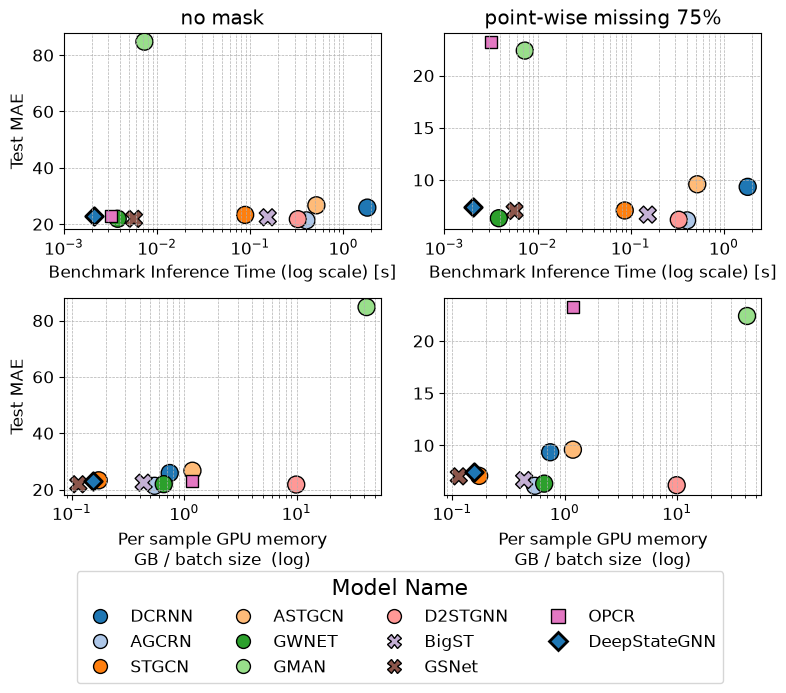

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
runs_inference_time_GBA = runs_inference_time_GBA.groupby(['mask_name', 'model_name']).mean(True).loc[:, ['benchmark_inference_mean_time', 'benchmark_inference_std_time']] 
grouped_gba_runs = runs_benchmark_GBA.groupby(['mask_name', 'model_name']).mean(True).loc[:, ['test_avg_mae']] 
grouped_gba_runs = grouped_gba_runs.join(global_category_df, on='model_name', how='left')


joined_metrics = grouped_gba_runs.join(runs_inference_time_GBA, on=['mask_name', 'model_name'])


mask_bla = (~ pd.isna(joined_metrics)).all(axis=1).reset_index().groupby('model_name').all().reset_index()
valid_models = mask_bla[mask_bla.iloc[:, 2]].model_name
joined_metrics = joined_metrics[joined_metrics.index.get_level_values('model_name').isin(valid_models)]


df = df_gpu_mem # pd.read_csv('model_parameters.csv')

# astgcn_org_gba = int(df.loc[df['Baseline'] == 'ASTGCN', 'GBA'].values[0])
# df.loc[df['Baseline'] == 'ASTGCN', 'GBA'] = 4_500_000

joined_metrics = joined_metrics.reset_index().set_index('model_name').join(df.set_index('Baseline').loc[:, ['GBA_mem_per_sample']].rename(columns={'GBA_mem_per_sample': 'model_paramters_gba'}), on='model_name').reset_index().set_index(['mask_name', 'model_name'])

# take all these model for which all the inference times are available and the test_avg_mae is available and model_paramters_gba is available
# joined_metrics = joined_metrics.dropna(subset=['benchmark_inference_mean_time', 'test_avg_mae', 'model_paramters_gba'])
joined_metrics = joined_metrics.rename(index={'DSGNN': 'DeepStateGNN'})

## set fontsize to 12
plt.rcParams.update({'font.size': 12})

import matplotlib.pyplot as plt
import seaborn as sns

mask_dictionary = {
    'no_mask': 'no mask',
    'point_missing_050': 'point-wise missing 50%',
    'point_missing_075': 'point-wise missing 75%',
    'point_missing_095': 'point-wise missing 95%',
    'tr_drop_025': 'unseen-sensor 25%',
    'tr_drop_050': 'unseen-sensor 50%',
    'tr_drop_075': 'unseen-sensor 75%',
}


fig = plt.figure(figsize=(9, 6))

mask_i = 0
for mask in joined_metrics.index.get_level_values('mask_name').unique():
    mask_data = joined_metrics.loc[mask].reset_index()
    mask_data = mask_data[mask_data.model_name != 'DeepStateGNN']
    # plt.errorbar(mask_data['benchmark_inference_mean_time'], mask_data['test_avg_mae'], yerr=mask_data['benchmark_inference_std_time'], fmt='o', label=mask)
    ax = fig.add_subplot(2, 2, mask_i + 1)
    
    sns.scatterplot(data=mask_data, x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax, legend = False, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=80, ax = ax, legend = False, edgecolor='black',marker='D', linewidth=2)
    # if mask_i == 3:
    #     sns.move_legend(ax, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
    ax.set_title(f'{mask_dictionary[mask]}')
    plt.xscale('log')
    ax.grid(True, which="both", ls="--", linewidth=0.5)
    
    ax.set_xlabel('Benchmark Inference Time (log scale) [s]')
    
    if mask_i == 0:
        ax.set_ylabel('Test MAE')
    else: 
        ax.set_ylabel(None)
    ax.set_xlim(10**-3, None)
    
    ax_model_para = fig.add_subplot(2, 2, mask_i + 1 + 2)
    
    ax_model_para.grid(True, which="both", ls="--", linewidth=0.5)
    sns.scatterplot(data=mask_data, x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax_model_para, legend = mask_i == 1, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=80, ax = ax_model_para, legend = mask_i == 1, edgecolor='black',marker='D', linewidth=2)
    if mask_i == 1:
        # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-.15, -.9), ncol=4, title='Model Name')
        
        # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
        handles, labels = ax_model_para.get_legend_handles_labels()
        label_index = labels.index('category')
        
        # change the shape of the handles to squares
        for i in range(1, label_index):
            handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
            handles[i].set_markersize(10)
        
        plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(-.14, -1), loc='lower center', ncol = 4, title_fontsize=16)
    ax_model_para.set_title(None)
    plt.xscale('log')
    
    # ax_model_para.set_xlabel('Trainable Model Parameters (log scale)')
    ax_model_para.set_xlabel('Per sample GPU memory\nGB / batch size  (log)')
    if mask_i == 0:
        ax_model_para.set_ylabel('Test MAE')
    else: 
        ax_model_para.set_ylabel(None)

    
    mask_i += 1
    # ax_model_para.set_xlim(10**5, None)
    
plt.subplots_adjust(hspace=.35)

    
    
# plt.tight_layout()
plt.savefig('img/inference_time_vs_mae_gba.png', dpi=300, bbox_inches='tight')

In [14]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["withMD", "benchmark_GBA", "benchmark_CA"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None, "tr_drop_025", "tr_drop_050", "tr_drop_075",'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)

100%|██████████| 876/876 [03:40<00:00,  3.98it/s]


In [15]:
new_SD_tr_runs = get_runs_with_filters({'$and': [{'tags': {"$in": ["tr_drop_SD"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [ None, "tr_drop_025", "tr_drop_050", "tr_drop_075"]}}]})

In [16]:
list_of_new_SD_tr_runs = extract_run_data(new_SD_tr_runs, access_metadata = False)

 50%|████▉     | 87/175 [00:24<00:24,  3.58it/s]

100%|██████████| 175/175 [00:46<00:00,  3.79it/s]


In [17]:
list_of_new_SD_tr_runs.loc[:, ['withMD']] = 'True'

runs_updated = pd.concat([
    runs.drop(
        runs[
            (runs['withMD'] == 'True').astype(bool) & 
            runs['mask_name'].isin(['tr_drop_025', 'tr_drop_050', 'tr_drop_075'])
        ].index
    ),
    list_of_new_SD_tr_runs
    ], ignore_index=True).astype({
        'test_dropped_available_sensors_avg_mae': float,
        'test_dropped_unavailable_sensors_avg_mae': float
    })

In [18]:
runs = runs_updated

sd_runs = runs[runs['withMD'] == 'True']
gba_runs = runs[runs['benchmark_GBA']]
ca_runs = runs[runs['benchmark_CA'] & (runs.dataset == 'CA')]
ca_runs = ca_runs[ca_runs['epochs'] > 1]

grouped_sd_runs = sd_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)
grouped_gba_runs = gba_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)
grouped_ca_runs = ca_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)

mask_list = ['no_mask', 'tr_drop_025', 'tr_drop_050', 'tr_drop_075']#, 'point_missing_050', 'point_missing_075', 'point_missing_095']
baseline_list = ['AGCRN','ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'GWNET', 'OPCR', 'PDFormer', 'SPIN', 'STGCN', 'STGode', 'DSGNN']

#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': '75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': '50\%',
    'tr_drop_075': '75\%',
}



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
mask_name_latex = [f"\multicolumn{{3}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {"& MAE & RMSE & MAPE " * len(mask_list)} \\\\')
print('\\hline')


is_first_baseline = True

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        sd_mae = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_rmse = grouped_sd_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_mape = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_sd_runs.index else -1
        
        print(f' & {sd_mae:.1f} & {sd_rmse:.1f} & {sd_mape:.1f}\\% ', end = "")
    print('\\\\')
    
    
    
    is_first_baseline = False
print('\\hline')
    

    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|c|l|rrr|rrr|rrr|rrr|}
Dataset & Baseline & \multicolumn{3}{c|}{0\%} & \multicolumn{3}{c|}{25\%} & \multicolumn{3}{c|}{50\%} & \multicolumn{3}{c|}{75\%} \\
 &  & MAE & RMSE & MAPE & MAE & RMSE & MAPE & MAE & RMSE & MAPE & MAE & RMSE & MAPE  \\
\hline
\multirow{14}{*}{SD} & AGCRN & 18.1 & 32.6 & 13.4\%  & 59.7 & 111.2 & 99.9\%  & 103.1 & 153.1 & 191.8\%  & 133.1 & 166.8 & 241.9\% \\
 & ASTGCN & 24.4 & 39.2 & 16.5\%  & 55.2 & 86.6 & 29.1\%  & 77.1 & 111.8 & 37.4\%  & 86.7 & 134.9 & 53.6\% \\
 & BigST & 18.7 & 30.9 & 13.0\%  & 35.6 & 56.0 & 25.0\%  & 40.6 & 60.4 & 32.8\%  & 36.6 & 55.4 & 31.2\% \\
 & D2STGNN & 17.3 & 29.1 & 11.7\%  & 31.6 & 51.7 & 22.6\%  & 41.7 & 64.7 & 34.8\%  & 71.5 & 101.3 & 77.1\% \\
 & DCRNN & 23.3 & 36.9 & 15.6\%  & -1.0 & -1.0 & -1.0\%  & -1.0 & -1.0 & -1.0\%  & -1.0 & -1.0 & -1.0\% \\
 & GMAN & 18.7 & 54.9 & 21.8\%  & 55.5 & 103.2 & 40.9\%  & 67.9 & 107.2 & 67.7\%  & 92.3 & 121.6 & 115.8\% \\
 & GSNet & 20.0 & 32.7 & 

In [19]:
sd_runs = runs[runs['withMD'] == 'True']
gba_runs = runs[runs['benchmark_GBA']]
ca_runs = runs[runs['benchmark_CA']]
ca_runs = ca_runs[ca_runs['epochs'] > 1]

grouped_sd_runs = sd_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)
grouped_gba_runs = gba_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)
grouped_ca_runs = ca_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)

mask_list = ['tr_drop_025', 'tr_drop_050', 'tr_drop_075']#, 'point_missing_050', 'point_missing_075', 'point_missing_095']
# mask_list = ['no_mask', 'tr_drop_025', 'tr_drop_050', 'tr_drop_075']#, 'point_missing_050', 'point_missing_075', 'point_missing_095']
# baseline_list = ['AGCRN','ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'GWNET', 'OPCR', 'STGCN', 'DSGNN']
baseline_list = ['COMLP', 'AGCRN','ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'GWNET', 'OPCR', 'PDFormer', 'SPIN', 'STGCN', 'STGode', 'DSGNN']


#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
number_column_pattern = '>{\\raggedleft\\arraybackslash}p{8mm}'
print('\\begin{tabular}{|l|'+number_column_pattern+'|' + (number_column_pattern * 4 + '|') * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': '75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': '50\%',
    'tr_drop_075': '75\%',
}



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
mask_name_latex = [f"\multicolumn{{4}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'\\hline')
print(f' \\multirow{{2}}{{*}}{{Baseline}} & 0\% & {(" & ".join(mask_name_latex))} \\\\')
print(f'\\cline{{2-14}}')
print(f'& all sensors {"&masked input (av.)&all input (av.)& all input (unav.)&knn inpterpolation (unav.)" * len(mask_list)} \\\\')
print('\\hline')

dataset = grouped_sd_runs

is_first_baseline = True

for baseline in baseline_list:
    if baseline == 'DSGNN':
        print(f'\\hline')
        
    print(f' {baseline}', end='')
    sd_mae_no_mask = dataset.loc[(baseline, 'no_mask'), 'test_avg_mae'] if (baseline, 'no_mask') in dataset.index else -1
    print(f' & {sd_mae_no_mask:.1f} ', end = "")
    
    
    for mask in mask_list:
        sd_av_mae = dataset.loc[(baseline, mask), 'test_available_sensors_avg_mae'] if (baseline, mask) in dataset.index else -1
        sd_dropped_av_mae = dataset.loc[(baseline, mask), 'test_dropped_available_sensors_avg_mae'] if (baseline, mask) in dataset.index else -1
        sd_unav_mae = dataset.loc[(baseline, mask), 'test_unavailable_sensors_avg_mae'] if (baseline, mask) in dataset.index else -1
        sd_knn_mae = dataset.loc[(baseline, mask), 'test_dropped_unavailable_sensors_avg_mae'] if (baseline, mask) in dataset.index else -1
        if baseline == 'DSGNN':
            print(f' & & {sd_av_mae:.1f} & {sd_unav_mae:.1f} &  ', end = "")
        else: 
            print(f' & \\textcolor{{black!70}}{{{sd_dropped_av_mae:.1f}}} & {sd_av_mae:.1f} & {sd_unav_mae:.1f} & \\textcolor{{black!70}}{{{sd_knn_mae:.1f}}} ', end = "")
    print('\\\\')
    
    is_first_baseline = False
print('\\hline')
    

    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|l|>{\raggedleft\arraybackslash}p{8mm}|>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}|>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}|>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}>{\raggedleft\arraybackslash}p{8mm}|}
\hline
 \multirow{2}{*}{Baseline} & 0\% & \multicolumn{4}{c|}{25\%} & \multicolumn{4}{c|}{50\%} & \multicolumn{4}{c|}{75\%} \\
\cline{2-14}
& all sensors &masked input (av.)&all input (av.)& all input (unav.)&knn inpterpolation (unav.)&masked input (av.)&all input (av.)& all input (unav.)&knn inpterpolation (unav.)&masked input (av.)&all input (av.)& all input (unav.)&knn inpterpolation (unav.) \\
\hline
 COMLP & 25.2  & \textcolor{black!70}{25.4} & 25.4 & 26.7 & \textcolor{black!70}{6

In [20]:
sd_runs = runs[runs['withMD'] == 'True']
gba_runs = runs[runs['benchmark_GBA']]
ca_runs = runs[runs['benchmark_CA']]
ca_runs = ca_runs[ca_runs['epochs'] > 1]

grouped_sd_runs = sd_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)
grouped_gba_runs = gba_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)
grouped_ca_runs = ca_runs.groupby(['model_name', 'mask_name']).mean(numeric_only=True)

mask_list = ['no_mask', 'tr_drop_025', 'tr_drop_050', 'tr_drop_075']#, 'point_missing_050', 'point_missing_075', 'point_missing_095']
# mask_list = ['no_mask', 'tr_drop_025', 'tr_drop_050', 'tr_drop_075']#, 'point_missing_050', 'point_missing_075', 'point_missing_095']
# baseline_list = ['AGCRN','ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'GWNET', 'OPCR', 'STGCN', 'DSGNN']
baseline_list = ['AGCRN','ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'GWNET', 'OPCR', 'PDFormer', 'SPIN', 'STGCN', 'STGode', 'DSGNN']


#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': '75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': '50\%',
    'tr_drop_075': '75\%',
}



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
mask_name_latex = [f"\multicolumn{{3}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {" AV(0s)& UNAV(K=5)" * len(mask_list)} \\\\')
print('\\hline')

dataset = grouped_sd_runs

is_first_baseline = True

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        # sd_mae = dataset.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in dataset.index else -1
        sd_av_mae = dataset.loc[(baseline, mask), 'test_dropped_available_sensors_avg_mae'] if (baseline, mask) in dataset.index else -1
        sd_unav_mae = dataset.loc[(baseline, mask), 'test_dropped_unavailable_sensors_avg_mae'] if (baseline, mask) in dataset.index else -1
        
        print(f' & {sd_av_mae:.1f} & {sd_unav_mae:.1f} ', end = "")
    print('\\\\')
    
    is_first_baseline = False
print('\\hline')
    

    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|c|l|rrr|rrr|rrr|rrr|}
Dataset & Baseline & \multicolumn{3}{c|}{0\%} & \multicolumn{3}{c|}{25\%} & \multicolumn{3}{c|}{50\%} & \multicolumn{3}{c|}{75\%} \\
 &   AV(0s)& UNAV(K=5) AV(0s)& UNAV(K=5) AV(0s)& UNAV(K=5) AV(0s)& UNAV(K=5) \\
\hline
\multirow{14}{*}{SD} & AGCRN & nan & nan  & 18.6 & 63.8  & 19.4 & 66.1  & 19.7 & 72.3 \\
 & ASTGCN & nan & nan  & 24.7 & 65.7  & 27.6 & 68.5  & 26.0 & 73.6 \\
 & BigST & nan & nan  & 20.4 & 64.1  & 19.7 & 66.3  & 24.0 & 73.4 \\
 & D2STGNN & nan & nan  & 17.6 & 63.2  & 17.8 & 65.9  & 18.1 & 72.0 \\
 & DCRNN & nan & nan  & -1.0 & -1.0  & -1.0 & -1.0  & -1.0 & -1.0 \\
 & GMAN & nan & nan  & 18.7 & 64.2  & 20.6 & 67.3  & 20.5 & 73.2 \\
 & GSNet & nan & nan  & 20.8 & 64.2  & 20.4 & 66.5  & 21.0 & 72.6 \\
 & GWNET & nan & nan  & 18.8 & 63.5  & 19.2 & 66.2  & 19.1 & 72.6 \\
 & OPCR & nan & nan  & 90.1 & 103.5  & 89.7 & 104.9  & 87.9 & 109.3 \\
 & PDFormer & nan & nan  & -1.0 & -1.0  & -1.0 & -1.0  & -1.0 & -1

In [21]:

mask_list = ['point_missing_050', 'point_missing_075', 'point_missing_095']

#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': '75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': '50\%',
    'tr_drop_075': '75\%',
}



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
mask_name_latex = [f"\multicolumn{{3}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {"& MAE & RMSE & MAPE " * len(mask_list)} \\\\')
print('\\hline')


is_first_baseline = True

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        sd_mae = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_rmse = grouped_sd_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_mape = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_sd_runs.index else -1
        
        print(f' & {sd_mae:.1f} & {sd_rmse:.1f} & {sd_mape:.1f}\\% ', end = "")
    print('\\\\')
    
    is_first_baseline = False
print('\\hline')
    

    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|c|l|rrr|rrr|rrr|}
Dataset & Baseline & \multicolumn{3}{c|}{50\%} & \multicolumn{3}{c|}{75\%} & \multicolumn{3}{c|}{95\%} \\
 &  & MAE & RMSE & MAPE & MAE & RMSE & MAPE & MAE & RMSE & MAPE  \\
\hline
\multirow{14}{*}{SD} & AGCRN & 9.7 & 25.4 & 7.2\%  & 5.3 & 19.6 & 3.9\%  & 1.2 & 10.0 & 0.9\% \\
 & ASTGCN & 16.6 & 37.7 & 12.7\%  & 9.6 & 30.9 & 7.6\%  & 2.5 & 17.1 & 2.0\% \\
 & BigST & 10.1 & 24.3 & 7.2\%  & 5.3 & 18.4 & 3.7\%  & 1.2 & 9.2 & 0.8\% \\
 & D2STGNN & 9.1 & 22.3 & 6.1\%  & 4.9 & 17.4 & 3.3\%  & 1.2 & 9.4 & 0.8\% \\
 & DCRNN & 11.7 & 26.7 & 8.1\%  & 6.4 & 21.1 & 4.6\%  & 1.7 & 12.4 & 1.3\% \\
 & GMAN & 10.9 & 51.2 & 12.6\%  & 6.2 & 44.8 & 5.6\%  & 1.8 & 36.1 & 1.6\% \\
 & GSNet & 11.5 & 27.0 & 8.0\%  & 6.4 & 21.1 & 4.5\%  & 1.5 & 10.8 & 1.0\% \\
 & GWNET & 9.4 & 22.6 & 6.6\%  & 5.1 & 17.7 & 3.6\%  & 1.5 & 11.3 & 1.2\% \\
 & OPCR & 36.6 & 80.9 & 49.9\%  & 24.8 & 68.9 & 35.7\%  & 6.0 & 34.5 & 8.9\% \\
 & PDFormer & 11.7 & 26.5 & 8.2

In [22]:
mask_list = ['no_mask', 'tr_drop_050', 'point_missing_075',]

#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
print("\caption{Performance results on the Greater Bay Area dataset for the no missing data, for 50\% unseen training sensors, and for 75\% point missing observations}")
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': 'Point Missing 75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': 'Unseen 50\%',
    'tr_drop_075': '75\%',
}

mask_name_latex = [f"\multicolumn{{4}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {"& MAE & RMSE & MAPE & Ep." * len(mask_list)} \\\\')
print('\\hline')

is_first_baseline = True

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{GBA}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        sd_mae = grouped_gba_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_gba_runs.index else 404
        
        if sd_mae <= grouped_gba_runs.xs(mask, level='mask_name')['test_avg_mae'].min():
            sd_mae_str = f'\\textbf{{{sd_mae:.1f}}}'
        else:
            sd_mae_str = f'{sd_mae:.1f}'
            # if baseline == 'DSGNN': 
            #     sd_mae_str += f' (+{(sd_mae - grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mae"].min()) / grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mae"].min() * 100:.1f}\%)'
        
        sd_rmse = grouped_gba_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_gba_runs.index else 404
        if sd_rmse <= grouped_gba_runs.xs(mask, level='mask_name')['test_avg_rmse'].min():
            sd_rmse_str = f'\\textbf{{{sd_rmse:.1f}}}'
        else:
            sd_rmse_str = f'{sd_rmse:.1f}'
            # if baseline == 'DSGNN':
            #     sd_rmse_str += f' (+{(sd_rmse - grouped_gba_runs.xs(mask, level="mask_name")["test_avg_rmse"].min()) / grouped_gba_runs.xs(mask, level="mask_name")["test_avg_rmse"].min() * 100:.1f}\%)'
        sd_mape = grouped_gba_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_gba_runs.index else 404 
        if sd_mape <= (grouped_gba_runs.xs(mask, level='mask_name')['test_avg_mape'] * 100).min():
            sd_mape_str = f'\\textbf{{{sd_mape:.1f}}}\\%'
        else:
            sd_mape_str = f'{sd_mape:.1f}\\%'
            # if baseline == 'DSGNN':
            #     sd_mape_str += f' (+{(sd_mape - (grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mape"] * 100).min()):.1f}\%)'
            
        sd_epochs = grouped_gba_runs.loc[(baseline, mask), 'epochs'] if (baseline, mask) in grouped_gba_runs.index else -1
        
        
        
        if ((mask == 'tr_drop_075') or (mask == 'tr_drop_025')):
            print(f' &  &  &', end = "")
        else:
        
            print(f' & {sd_mae_str} & {sd_rmse_str} & {sd_mape_str} & {int(sd_epochs)}', end = "")
    print('\\\\')
    
    is_first_baseline = False
    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\caption{Performance results on the Greater Bay Area dataset for the no missing data, for 50\% unseen training sensors, and for 75\% point missing observations}
\begin{tabular}{|c|l|rrrr|rrrr|rrrr|}
Dataset & Baseline & \multicolumn{4}{c|}{0\%} & \multicolumn{4}{c|}{Unseen 50\%} & \multicolumn{4}{c|}{Point Missing 75\%} \\
 &  & MAE & RMSE & MAPE & Ep.& MAE & RMSE & MAPE & Ep.& MAE & RMSE & MAPE & Ep. \\
\hline
\multirow{14}{*}{GBA} & AGCRN & \textbf{21.3} & 34.9 & \textbf{16.9}\% & 63 & 77.6 & 102.5 & 131.7\% & 35 & \textbf{6.1} & 20.0 & \textbf{5.0}\% & 63\\
 & ASTGCN & 26.7 & 43.7 & 26.0\% & 48 & 35.2 & 50.9 & 37.8\% & 37 & 9.6 & 28.2 & 9.8\% & 46\\
 & BigST & 22.4 & 35.3 & 20.1\% & 59 & 34.0 & 49.2 & 39.8\% & 41 & 6.7 & 21.1 & 6.2\% & 43\\
 & D2STGNN & 21.8 & 35.0 & 17.0\% & 11 & 41.8 & 61.7 & 43.2\% & 11 & 6.2 & \textbf{19.9} & 5.1\% & 11\\
 & DCRNN & 25.9 & 39.4 & 22.7\% & 24 & 61.4 & 85.4 & 47.1\% & 24 & 9.3 & 26.4 & 9.3\% & 24\\
 & GMAN & 84.8 & 11

In [23]:
"""

CA Baseline results 

"""



mask_list = ['no_mask', 'tr_drop_050', 'point_missing_075',]

#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
print("\caption{Performance results on the Greater Bay Area dataset for the no missing data, for 50\% unseen training sensors, and for 75\% point missing observations}")
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': 'Point Missing 75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': 'Unseen 50\%',
    'tr_drop_075': '75\%',
}

mask_name_latex = [f"\multicolumn{{4}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {"& MAE & RMSE & MAPE & Ep." * len(mask_list)} \\\\')
print('\\hline')

is_first_baseline = True
baseline_list = ['ASTGCN', 'BigST', 'DCRNN', 'GSNet', 'GWNet', 'OPCR', 'SPIN', 'STGCN', 'DSGNN']

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{GBA}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        sd_mae = grouped_ca_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_ca_runs.index else 404
        
        if sd_mae <= grouped_ca_runs.xs(mask, level='mask_name')['test_avg_mae'].min():
            sd_mae_str = f'\\textbf{{{sd_mae:.1f}}}'
        else:
            sd_mae_str = f'{sd_mae:.1f}'
            # if baseline == 'DSGNN': 
            #     sd_mae_str += f' (+{(sd_mae - grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mae"].min()) / grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mae"].min() * 100:.1f}\%)'
        
        sd_rmse = grouped_ca_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_ca_runs.index else 404
        if sd_rmse <= grouped_ca_runs.xs(mask, level='mask_name')['test_avg_rmse'].min():
            sd_rmse_str = f'\\textbf{{{sd_rmse:.1f}}}'
        else:
            sd_rmse_str = f'{sd_rmse:.1f}'
            # if baseline == 'DSGNN':
            #     sd_rmse_str += f' (+{(sd_rmse - grouped_ca_runs.xs(mask, level="mask_name")["test_avg_rmse"].min()) / grouped_ca_runs.xs(mask, level="mask_name")["test_avg_rmse"].min() * 100:.1f}\%)'
        sd_mape = grouped_ca_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_ca_runs.index else 404 
        if sd_mape <= (grouped_ca_runs.xs(mask, level='mask_name')['test_avg_mape'] * 100).min():
            sd_mape_str = f'\\textbf{{{sd_mape:.1f}}}\\%'
        else:
            sd_mape_str = f'{sd_mape:.1f}\\%'
            # if baseline == 'DSGNN':
            #     sd_mape_str += f' (+{(sd_mape - (grouped_ca_runs.xs(mask, level="mask_name")["test_avg_mape"] * 100).min()):.1f}\%)'
            
        sd_epochs = grouped_ca_runs.loc[(baseline, mask), 'epochs'] if (baseline, mask) in grouped_ca_runs.index else -1
        
        
        
        if ((mask == 'tr_drop_075') or (mask == 'tr_drop_025')):
            print(f' &  &  &', end = "")
        else:
        
            print(f' & {sd_mae_str} & {sd_rmse_str} & {sd_mape_str} & {int(sd_epochs)}', end = "")
    print('\\\\')
    
    is_first_baseline = False
    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\caption{Performance results on the Greater Bay Area dataset for the no missing data, for 50\% unseen training sensors, and for 75\% point missing observations}
\begin{tabular}{|c|l|rrrr|rrrr|rrrr|}
Dataset & Baseline & \multicolumn{4}{c|}{0\%} & \multicolumn{4}{c|}{Unseen 50\%} & \multicolumn{4}{c|}{Point Missing 75\%} \\
 &  & MAE & RMSE & MAPE & Ep.& MAE & RMSE & MAPE & Ep.& MAE & RMSE & MAPE & Ep. \\
\hline
\multirow{9}{*}{GBA} & ASTGCN & 31.4 & 47.2 & 26.3\% & 3 & 37.9 & 54.1 & 35.2\% & 3 & 49.3 & 77.3 & 41.5\% & 36\\
 & BigST & 21.7 & 34.5 & 15.9\% & 50 & 36.0 & 53.7 & 34.2\% & 50 & 27.0 & 50.6 & 17.1\% & 50\\
 & DCRNN & 40.1 & 56.9 & 28.0\% & 8 & 89.4 & 118.2 & 115.7\% & 8 & 41.4 & 62.7 & 33.3\% & 33\\
 & GSNet & \textbf{20.4} & \textbf{33.0} & \textbf{14.0}\% & 50 & 47.8 & 68.8 & 30.6\% & 35 & 30.1 & 53.6 & 18.7\% & 50\\
 & GWNet & 22.8 & 35.7 & 16.5\% & 14 & 33.5 & 48.6 & 25.3\% & 13 & 26.6 & 41.4 & 19.4\% & 14\\
 & OPCR & 81.5 & 114.2 & 75.9\% & 

## Parameter Scaling 

/tmp/ipykernel_2778709/1889812327.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 8e6)


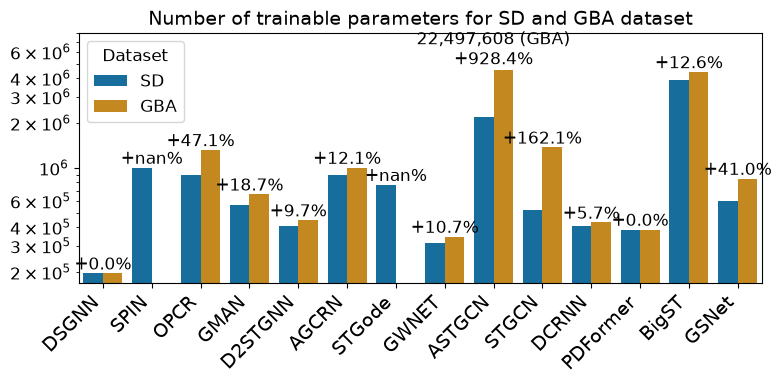

In [24]:
import pandas as pd

#set fontsize


df = pd.read_csv('model_parameters.csv')

astgcn_org_gba = int(df.loc[df['Baseline'] == 'ASTGCN', 'GBA'].values[0])
df.loc[df['Baseline'] == 'ASTGCN', 'GBA'] = 4_500_000

### columns: Baseline, SD, GBA

## make a figure as barplot with two bars per Baseline showing the numbers of SD and GBA paramters in a direct comparison
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.barplot(data=df.melt(id_vars='Baseline', var_name='Model', value_name
='Parameters'), x='Baseline', y='Parameters', hue='Model', palette='colorblind')
plt.title('Number of trainable parameters for SD and GBA dataset', fontsize=14)
# plt.ylabel('Number of Parameters (log)', fontsize=12)
plt.ylabel(None)
plt.yscale('log')
plt.xlabel(None)
plt.legend( title='Dataset', fontsize=12)#

##set the xticks labels in a 45° angle
plt.xticks(rotation=45, ha='right', fontsize=14)

plt.ylim(0, 8e6)

# write on top of each pair of bars the percentage difference between SD and GBA parameters
for index, row in df.iterrows():
    if row['Baseline'] == 'ASTGCN':
        sd_params = row['SD']
        gba_params = row['GBA']
        plt.text(index, max(sd_params, gba_params) * 1.1, f'{astgcn_org_gba:,} (GBA)\n+{(astgcn_org_gba - sd_params) / sd_params * 100:.1f}%', ha='center')
        # plt.bar(index - 0.2, sd_params, width=0.4, color='blue', alpha=0.5)
        # plt.bar(index + 0.2, gba_params, width=0.4, color='orange', alpha=0.5)
        
    else:
        sd_params = row['SD']
        gba_params = row['GBA']
        percentage_diff = (gba_params - sd_params) / sd_params * 100
        plt.text(index, max(sd_params, gba_params) * 1.06, f'+{percentage_diff:.1f}%', ha='center')
        
## cut the largest bar ASTGCN to make the plot more readable, but write the real number of parameters on top of the bar
# for index, row in df.iterrows():
#     if row['Baseline'] == 'ASTGCN':
#         sd_params = row['SD']
#         gba_params = row['GBA']
#         plt.text(index, max(sd_params, gba_params) * 1.06, f'{sd_params:,} (SD)\n{gba_params:,} (GBA)', ha='center')
#         plt.bar(index - 0.2, sd_params, width=0.4, color='blue', alpha=0.5)
#         plt.bar(index + 0.2, gba_params, width=0.4, color='orange', alpha=0.5)

plt.tight_layout()
# plt.show()

plt.savefig('img/model_parameters_comparison.png', dpi=300)

## Runtime comparison

In [25]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["benchmark_time"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [ "tr_drop_025", "tr_drop_050", "tr_drop_075"]}}]}), access_metadata = False)

100%|██████████| 78/78 [00:19<00:00,  4.08it/s]


In [26]:
is_H100 = runs.loc[:, 'gpu_type'] == 'NVIDIA H100 PCIe'
is_V100 = runs.loc[:, 'gpu_type'] == 'Tesla V100-SXM2-32GB'

model_filter = runs.loc[:, 'model_name'].isin(['DSGNN', 'BigST', 'GSNet', 'STGCN', 'GWNET', 'PDFormer'])
dataset_filter_SD = runs.loc[:, 'dataset'] == 'SD'

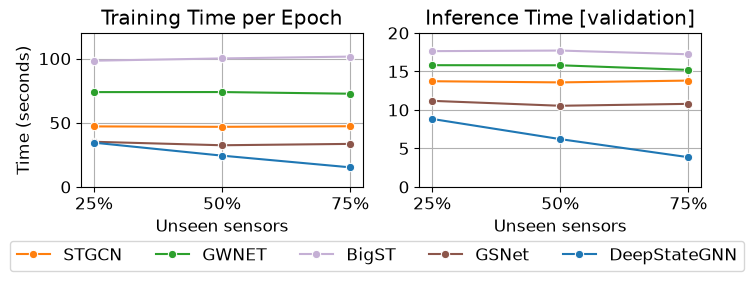

In [27]:
filtered_runs = runs.loc[model_filter & dataset_filter_SD ,:]
grouped_runs = filtered_runs.groupby(['model_name', filtered_runs.mask_name.fillna('None')]).mean(True)[['train_time_per_epoch', 'val_time']]

# grouped runs rename index value DSGNN into DeepStateGNN(our)
grouped_runs = grouped_runs.rename(index={'DSGNN': 'DeepStateGNN'})


## make a line plot in which each model_name group has its own line of the train_time_per_epoch column for all thesex values that are available in the mask_name

import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(8,2))


## make two plots left and rigfht to each other for val_time and train_time
ax = fig.add_subplot(1,2,1)


sns.lineplot(data=grouped_runs.reset_index(), x='mask_name', y='train_time_per_epoch', hue='model_name', marker='o', linestyle='-', ax = ax, legend=False, palette = global_color_dict, hue_order=[model for model in global_ordering if model in grouped_runs.reset_index().model_name.unique()])
plt.title('Training Time per Epoch')
plt.ylabel('Time (seconds)')
plt.xlabel('Unseen sensors')
# set x_tick labels to 0%, 25%, 50%, 75%
plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=[ '25%', '50%', '75%'])
# plt.yscale('log')
plt.grid(True)
plt.ylim(0, 120)

## put the legend putside the plot on the right

ax = fig.add_subplot(1,2,2)
sns.lineplot(data=grouped_runs.reset_index(), x='mask_name', y='val_time', hue='model_name', marker='o', linestyle='-', ax = ax, palette = global_color_dict, hue_order=[model for model in global_ordering if model in grouped_runs.reset_index().model_name.unique()])
sns.move_legend(ax, "lower center", bbox_to_anchor=(-.15, -.6), ncol=5, title=None)

# plt.legend(title='Model Name',  loc='outside lower center')

# plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25),
        #   ncol=6, fancybox=True, shadow=True)
plt.ylabel(None)
plt.title('Inference Time [validation]')
plt.xlabel('Unseen sensors')

plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=[ '25%', '50%', '75%'])
# plt.yscale('log')
plt.grid(True)
plt.ylim(0,20)



# fig.tight_layout()
# plt.tight_layout()
plt.savefig('img/training_time_per_epoch_H100.png', dpi=300, bbox_inches='tight')

In [28]:
joined_frame = runs[runs.dataset == 'SD'].set_index(['model_name', 'mask_name']).join(runs[runs.dataset == 'GBA'].set_index(['model_name', 'mask_name']), on = ['model_name', 'mask_name'], lsuffix = '_SD', rsuffix = '_GBA')

joined_frame['ratio_train'] = joined_frame.apply(lambda row: row['train_time_per_epoch_GBA'] / row['train_time_per_epoch_SD'] if (row['train_time_per_epoch_SD'] > 0 and row['train_time_per_epoch_GBA'] > 0) else None, axis=1)

joined_frame['ratio_val'] = joined_frame.apply(lambda row: row['val_time_GBA'] / row['val_time_SD'] if (row['val_time_SD'] > 0 and row['val_time_GBA'] > 0) else None, axis=1)

joined_frame[['ratio_train', 'ratio_val']]

,,ratio_train,ratio_val
model_name,mask_name,,
BigST,tr_drop_025,3.573359,3.961836
GSNet,tr_drop_025,4.369053,4.511612
AGCRN,tr_drop_025,6.454918,5.602709
ASTGCN,tr_drop_025,7.533345,5.954101
DCRNN,tr_drop_025,3.499584,3.708296
D2STGNN,tr_drop_025,12.604079,10.669019
STGCN,tr_drop_025,4.320208,4.542288
GWNET,tr_drop_025,5.237007,5.320780
GMAN,tr_drop_025,8.771691,8.605945


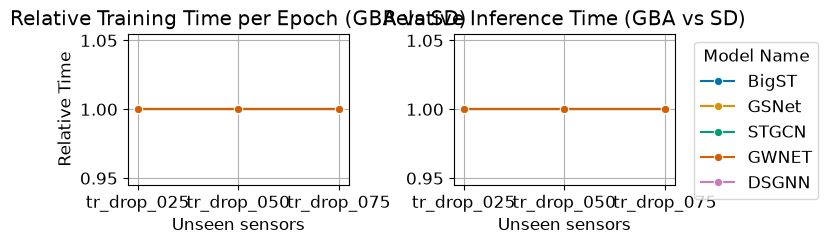

In [29]:
## group by model_name and mask_name and then there will be two lines for the SD dataset and the GBA. Now divide the train_time_per_epoch and val_time of the GBA by the corresponding values of the SD to get a relative training and inference time compared to the SD dataset. Then plot this relative time in a line plot with the same x axis and hue as before. This will show how much slower or faster the training and inference time is on the GBA compared to the SD dataset for each model and mask type.

filtered_runs.loc[:, 'relative_train_time'] = filtered_runs.apply(lambda row: row['train_time_per_epoch'] / grouped_runs.loc[(row['model_name'], row['mask_name']), 'train_time_per_epoch'] if (row['model_name'], row['mask_name']) in grouped_runs.index else None, axis=1)

filtered_runs.loc[:, 'relative_val_time'] = filtered_runs.apply(lambda row: row['val_time'] / grouped_runs.loc[(row['model_name'], row['mask_name']), 'val_time'] if (row['model_name'], row['mask_name']) in grouped_runs.index else None, axis=1)

fig = plt.figure(figsize=(8, 2.6))

ax = fig.add_subplot(1,2,1)
sns.lineplot(data=filtered_runs.reset_index(), x='mask_name', y='relative_train_time', hue='model_name', marker='o', linestyle='-', ax = ax, legend=False, palette = 'colorblind')
plt.title('Relative Training Time per Epoch (GBA vs SD)')
plt.ylabel('Relative Time')
plt.xlabel('Unseen sensors')
# plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=['0%', '25%', '50%', '75%'])
plt.grid(True)
ax = fig.add_subplot(1,2,2)
sns.lineplot(data=filtered_runs.reset_index(), x='mask_name', y='relative_val_time', hue='model_name', marker='o', linestyle='-', ax = ax, palette = 'colorblind')
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel(None)
plt.title('Relative Inference Time (GBA vs SD)')
plt.xlabel('Unseen sensors')
# plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=['0%', '25%', '50%', '75%'])
plt.grid(True)
plt.tight_layout()
# plt.savefig('img/relative_training_time_H100.png', dpi=300)

## Ablation Studies

In [30]:
ablation_dsn_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_dsn_embed_dim"]}}, {'state': 'finished'}]}))


 90%|█████████ | 19/21 [00:16<00:01,  1.21it/s]

100%|██████████| 21/21 [00:17<00:00,  1.17it/s]


In [31]:
## max min scale the test_avg_mae column for each model_name and mask_name combination and plot the results in a barplot
ablation_dsn_runs['test_avg_mae_scaled'] = ablation_dsn_runs.groupby(['model_name', 'mask_name'])['test_avg_mae'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

<Axes: xlabel='mask_name', ylabel='test_avg_mae'>

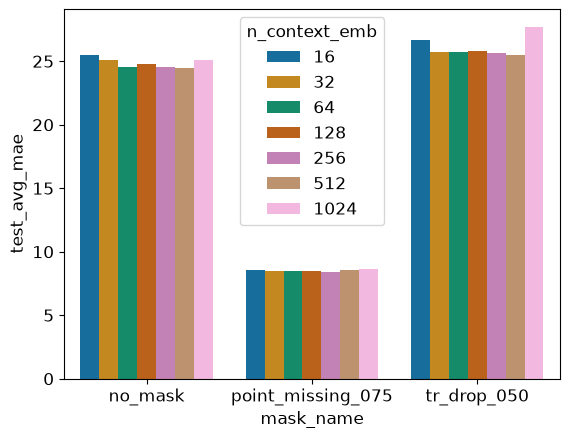

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=ablation_dsn_runs, x='mask_name', y='test_avg_mae', hue='n_context_emb', palette='colorblind')

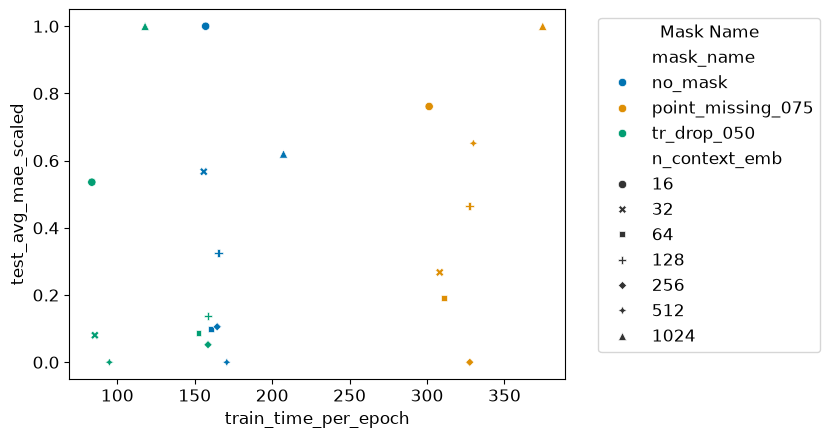

In [33]:
sns.scatterplot(data=ablation_dsn_runs, x='train_time_per_epoch', y='test_avg_mae_scaled', hue='mask_name', palette='colorblind', legend=True, style='n_context_emb')

plt.legend(title='Mask Name', bbox_to_anchor=(1.05, 1), loc='upper left')

## Ablation GCN Layers

In [34]:
ablation_gcn_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_gcn_layers"]}}, {'state': 'finished'}]}))
ablation_gcn_runs

100%|██████████| 30/30 [00:24<00:00,  1.21it/s]


,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,static_prefilter_leave_out,gcn_layers,...,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,benchmark_CA,train_mask
0,DSGNN,no_mask,0,SD,NVIDIA H100 PCIe,64,16,static_dsn,None,1,...,DSGNN_SD_2019_DSGNN_nomask_2026-03-31 18:13,100,finished,[ablation_gcn_layers],None,10.231578,False,False,False,False
1,DSGNN,no_mask,0,SD,NVIDIA H100 PCIe,64,16,static_dsn,None,0,...,DSGNN_SD_2019_DSGNN_nomask_2026-03-31 18:13,100,finished,[ablation_gcn_layers],None,9.873918,False,False,False,False
2,DSGNN,no_mask,0,SD,NVIDIA H100 PCIe,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_nomask_2026-03-31 19:29,100,finished,[ablation_gcn_layers],None,10.051460,False,False,False,False
3,DSGNN,no_mask,0,SD,NVIDIA H100 PCIe,64,16,static_dsn,None,3,...,DSGNN_SD_2019_DSGNN_nomask_2026-03-31 19:30,100,finished,[ablation_gcn_layers],None,10.272510,False,False,False,False
4,DSGNN,tr_drop_050,0,SD,NVIDIA H100 PCIe,64,16,static_dsn,None,0,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-03-31 1...,100,finished,[ablation_gcn_layers],None,6.006560,False,False,False,False
5,DSGNN,tr_drop_050,0,SD,Tesla V100-SXM2-32GB,64,16,static_dsn,None,1,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-03-31 1...,100,finished,[ablation_gcn_layers],None,10.086340,False,False,False,False
6,DSGNN,tr_drop_050,0,SD,Tesla V100-SXM2-32GB,64,16,static_dsn,None,3,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-03-31 2...,100,finished,[ablation_gcn_layers],None,10.419331,False,False,False,False
7,DSGNN,tr_drop_050,0,SD,Tesla V100-SXM2-32GB,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-03-31 2...,100,finished,[ablation_gcn_layers],None,10.277009,False,False,False,False
8,DSGNN,point_missing_075,0,SD,NVIDIA H100 PCIe,64,16,static_dsn,None,0,...,DSGNN_SD_2019_DSGNN_point_missing_075_0_2026-0...,100,finished,[ablation_gcn_layers],None,10.822252,False,False,False,False
9,DSGNN,point_missing_075,0,SD,NVIDIA H100 PCIe,64,16,static_dsn,None,1,...,DSGNN_SD_2019_DSGNN_point_missing_075_0_2026-0...,100,finished,[ablation_gcn_layers],None,10.652817,False,False,False,False


In [35]:
ablation_gcn_runs['test_avg_mae_scaled'] = ablation_gcn_runs.groupby(['model_name', 'mask_name'])['test_avg_mae'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))



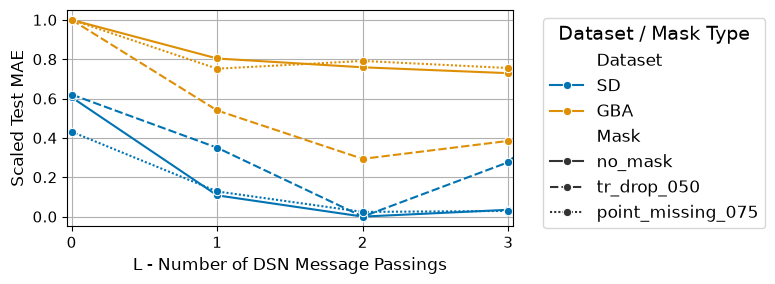

In [36]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 3))

ax = fig.add_subplot(1, 1, 1)

ablation_gcn_runs = ablation_gcn_runs.rename(columns ={'mask_name': 'Mask', 'dataset': 'Dataset'} )


sns.lineplot(data=ablation_gcn_runs, style='Mask', x='gcn_layers', y='test_avg_mae_scaled', hue='Dataset', palette='colorblind', marker='o', legend='brief', ax = ax)
ax.set_title(None)
ax.set_xlabel('L - Number of DSN Message Passings', fontsize = 12)
ax.set_ylabel('Scaled Test MAE', fontsize = 12)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
ax.grid(True)
plt.legend(title='Dataset / Mask Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)
ax.set_xticks([0,1,2,3])
ax.set_xlim(-.03,3.03)
plt.tight_layout()
plt.savefig('img/ablation_gcn_layers.png', dpi=300)

In [37]:
ablation_concat_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_concat_queries"]}}, {'state': 'finished'}]}))

100%|██████████| 6/6 [00:05<00:00,  1.12it/s]


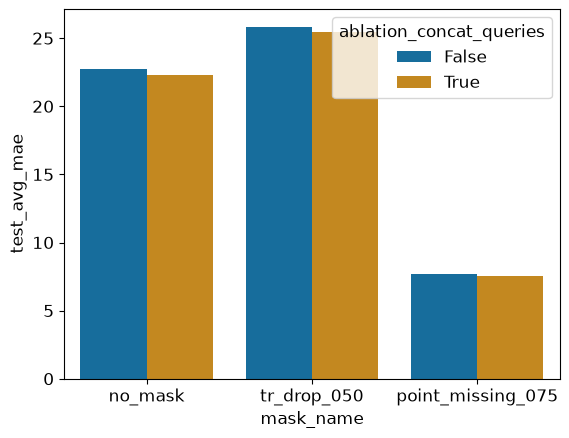

In [38]:
ablation_concat_runs['test_avg_mae_scaled'] = ablation_concat_runs.groupby(['model_name', 'mask_name'])['test_avg_mae'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

sns.barplot(data=ablation_concat_runs, x='mask_name', y='test_avg_mae', hue='ablation_concat_queries', palette='colorblind')

plt.savefig('img/concat_queries.png', dpi = 300)

## Ablation static_mode

In [39]:
ablation_static_mode_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_static_prefilter_mode", "ablation_static_prefilter_dsn_type"]}}, {'state': 'finished'}]}),  access_metadata = False)
ablation_static_mode_runs.columns

 68%|██████▊   | 93/136 [00:25<00:10,  4.23it/s]

100%|██████████| 136/136 [00:36<00:00,  3.76it/s]


Index(['model_name', 'mask_name', 'mask_iter', 'dataset', 'gpu_type',
       'n_context_emb', 'n_hid', 'static_prefilter_mode',
       'static_prefilter_leave_out', 'gcn_layers', 'ablation_concat_queries',
       'dsn_div_weight', 'dsn_div_margin', 'attention_method', 'dropout',
       'n_context', 'test_avg_mae', 'test_available_sensors_avg_mae',
       'test_dropped_available_sensors_avg_mae',
       'test_unavailable_sensors_avg_mae',
       'test_dropped_unavailable_sensors_avg_mae', 'train_time_per_epoch',
       'benchmark_inference_mean_time', 'benchmark_inference_std_time',
       'test_avg_mape', 'test_avg_rmse', 'name', 'epochs', 'state', 'tags',
       'val_loss', 'val_time', 'withMD', 'benchmark_GBA', 'benchmark_CA',
       'train_mask'],
      dtype='str')

In [40]:
ablation_fixed_context_runs = ablation_static_mode_runs[pd.isna(ablation_static_mode_runs.static_prefilter_leave_out)]

In [41]:
ablation_fixed_context_runs = ablation_static_mode_runs.groupby(['mask_name', 'static_prefilter_mode', 'n_context'])[['test_avg_mae', 'test_available_sensors_avg_mae', 'test_unavailable_sensors_avg_mae', 'train_time_per_epoch', 'val_time']].mean()
ablation_fixed_context_runs

test_avg_mae  \
mask_name         static_prefilter_mode n_context                 
no_mask           fixed                 50            24.567796   
                                        100           23.504511   
                                        200           22.386436   
                                        350           21.283917   
                  identity              64            22.170977   
                  none                  50            25.313227   
                                        100           24.926527   
                                        200           24.520616   
                                        350           24.872113   
                  static_dsn            32            24.121796   
                                        64            22.924472   
point_missing_075 fixed                 50             8.349364   
                                        100            8.689603   
                                        200            8.192079   
                                        350            7.016790   
                  identity              64             7.376804   
                  none                  50             8.433984   
                                        100            8.179265   
                                        200            8.284786   
                                        350            8.294543   
                  static_dsn            32            37.439864   
                                        64             7.768051   
tr_drop_050       fixed                 50            37.757806   
                                        100           39.427740   
                                        200           42.742013   
                                        350           41.682095   
                  identity              64            95.377392   
                  none                  50            26.743078   
                                        100           26.647833   
                                        200           27.636631   
                                        350           27.629840   
                  static_dsn            32            25.656870   
                                        64            24.822192   
tr_drop_075       fixed                 50            47.652403   
                                        100           52.197127   
                                        200           47.249973   
                                        350           53.178489   
                  identity              64            98.904498   
                  none                  50            32.326288   
                                        100           35.291103   
                                        200           33.888247   
                                        350           38.642439   
                  static_dsn            32            29.536645   
                                        64            29.090584   

                                                   test_available_sensors_avg_mae  \
mask_name         static_prefilter_mode n_context                                   
no_mask           fixed                 50                                    NaN   
                                        100                                   NaN   
                                        200                                   NaN   
                                        350                                   NaN   
                  identity              64                                    NaN   
                  none                  50                                    NaN   
                                        100                                   NaN   
                                        200                                   NaN   
                                        350                                   NaN   
                  static_dsn     

In [42]:
# print Latex table header


print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|l|' + 'r|r|rrrr|rrrr|')



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f' & Identity & DeepStateGNN & \multicolumn{{4}}{{c|}}{{Fixed}} & \multicolumn{{4}}{{c|}}{{Dynamic}} \\\\')
print(f'Number of DSNs: & |$\\mathcal{{S}}|$| & 56 & 50 & 100 & 200 & 300 & 50 & 100 & 200 & 300 \\\\')
print('\\hline')


# is_first_baseline = True

# for baseline in baseline_list:
#     if is_first_baseline:
#             print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
#     print(f' & {baseline}', end='')
#     for mask in mask_list:
#         sd_mae = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_sd_runs.index else -1
#         sd_rmse = grouped_sd_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_sd_runs.index else -1
#         sd_mape = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_sd_runs.index else -1
        
#         print(f' & {sd_mae:.1f} & {sd_rmse:.1f} & {sd_mape:.1f}\\% ', end = "")
#     print('\\\\')
    
#     is_first_baseline = False
# print('\\hline')
    

mask_dictionary = {
    'no_mask': 'No Mask',
    'point_missing_075': '75\% point missing',
    'tr_drop_050': '50\% unseen sensors',
    'tr_drop_075': '75\% unseen sensors',
}
    
    


for mask in ablation_fixed_context_runs.index.get_level_values('mask_name').unique():
    mask_data = ablation_fixed_context_runs.xs(mask, level='mask_name')
    
    identity_mae = mask_data.xs(('identity', 64), level=['static_prefilter_mode', 'n_context'])['test_avg_mae'].values[0] 
    
    deepstate_mae = mask_data.xs(('static_dsn', 64), level=['static_prefilter_mode', 'n_context'])['test_avg_mae'].values[0]
    
    print(f'{mask_dictionary[mask]} & {identity_mae:.1f} & {deepstate_mae:.1f} ', end='')
    for mode in ['fixed', 'none']:
        for n_context in [50, 100, 200, 350]:
            mae = mask_data.xs((mode, n_context), level=['static_prefilter_mode', 'n_context'])['test_avg_mae'].values[0]
            print(f'& {mae:.1f} ', end='')
            
    print('\\\\')
        

        
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|l|r|r|rrrr|rrrr|
 & Identity & DeepStateGNN & \multicolumn{4}{c|}{Fixed} & \multicolumn{4}{c|}{Dynamic} \\
Number of DSNs: & |$\mathcal{S}|$| & 56 & 50 & 100 & 200 & 300 & 50 & 100 & 200 & 300 \\
\hline
No Mask & 22.2 & 22.9 & 24.6 & 23.5 & 22.4 & 21.3 & 25.3 & 24.9 & 24.5 & 24.9 \\
75\% point missing & 7.4 & 7.8 & 8.3 & 8.7 & 8.2 & 7.0 & 8.4 & 8.2 & 8.3 & 8.3 \\
50\% unseen sensors & 95.4 & 24.8 & 37.8 & 39.4 & 42.7 & 41.7 & 26.7 & 26.6 & 27.6 & 27.6 \\
75\% unseen sensors & 98.9 & 29.1 & 47.7 & 52.2 & 47.2 & 53.2 & 32.3 & 35.3 & 33.9 & 38.6 \\
\end{tabular}
\end{table*}


In [43]:
ablation_dyn_type_runs = ablation_static_mode_runs[ablation_static_mode_runs.tags.apply(lambda x: x[0]) == 'ablation_static_prefilter_dsn_type']

ablation_dyn_type_runs.loc[pd.isna(ablation_static_mode_runs.static_prefilter_leave_out), 'static_prefilter_leave_out'] = 'all dsns'
ablation_dyn_type_runs = ablation_dyn_type_runs.groupby(['mask_name', 'static_prefilter_mode', 'static_prefilter_leave_out'])[['test_avg_mae', 'test_available_sensors_avg_mae', 'test_unavailable_sensors_avg_mae', 'train_time_per_epoch', 'val_time']].mean()

In [44]:

print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|l|' + 'rrrrrr}')



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Number of DSNs: & baseline & w/o direction & w/o neighborhoods & w/o lane_number & w/o region & w/o roads \\\\')
print('\\hline')


# is_first_baseline = True

# for baseline in baseline_list:
#     if is_first_baseline:
#             print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
#     print(f' & {baseline}', end='')
#     for mask in mask_list:
#         sd_mae = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_sd_runs.index else -1
#         sd_rmse = grouped_sd_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_sd_runs.index else -1
#         sd_mape = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_sd_runs.index else -1
        
#         print(f' & {sd_mae:.1f} & {sd_rmse:.1f} & {sd_mape:.1f}\\% ', end = "")
#     print('\\\\')
    
#     is_first_baseline = False
# print('\\hline')
    

mask_dictionary = {
    'no_mask': 'No Mask',
    'point_missing_075': '75\% point missing',
    'tr_drop_050': '50\% unseen sensors',
    'tr_drop_075': '75\% unseen sensors',
}
    
    


for mask in ablation_dyn_type_runs.index.get_level_values('mask_name').unique():
    mask_data = ablation_dyn_type_runs.xs(mask, level='mask_name')
    
    all_dsns_mae = mask_data.xs(('static_dsn', 'all dsns'), level=['static_prefilter_mode', 'static_prefilter_leave_out'])['test_avg_mae'].values[0] 
    wo_dir_mae = mask_data.xs(('static_dsn', 'direction'), level=['static_prefilter_mode', 'static_prefilter_leave_out'])['test_avg_mae'].values[0] 
    wo_neigh_mae = mask_data.xs(('static_dsn', 'neighborhoods'), level=['static_prefilter_mode', 'static_prefilter_leave_out'])['test_avg_mae'].values[0] 
    wo_lanes_mae = mask_data.xs(('static_dsn', 'num_lanes'), level=['static_prefilter_mode', 'static_prefilter_leave_out'])['test_avg_mae'].values[0] 
    wo_region_mae = mask_data.xs(('static_dsn', 'region'), level=['static_prefilter_mode', 'static_prefilter_leave_out'])['test_avg_mae'].values[0] 
    wo_roads_mae = mask_data.xs(('static_dsn', 'road'), level=['static_prefilter_mode', 'static_prefilter_leave_out'])['test_avg_mae'].values[0] 
    
    
    
    
    
    
    print(f'{mask_dictionary[mask]} & {all_dsns_mae:.1f} & {wo_dir_mae:.1f} & {wo_neigh_mae:.1f} & {wo_lanes_mae:.1f} & {wo_region_mae:.1f} & {wo_roads_mae:.1f} ', end='')
            
    print('\\\\')
        

        
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|l|rrrrrr}
Number of DSNs: & baseline & w/o direction & w/o neighborhoods & w/o lane_number & w/o region & w/o roads \\
\hline
No Mask & 23.6 & 23.9 & 24.7 & 24.1 & 23.7 & 24.8 \\
75\% point missing & 37.0 & 36.9 & 38.0 & 37.6 & 36.7 & 38.4 \\
50\% unseen sensors & 25.6 & 25.5 & 26.0 & 25.7 & 25.5 & 25.7 \\
75\% unseen sensors & 28.6 & 28.9 & 31.0 & 29.1 & 29.7 & 29.9 \\
\end{tabular}
\end{table*}


## Ablation hidden dim

In [45]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_hidden_dim"]}}, {'state': 'finished'}]}))    

100%|██████████| 21/21 [00:17<00:00,  1.22it/s]


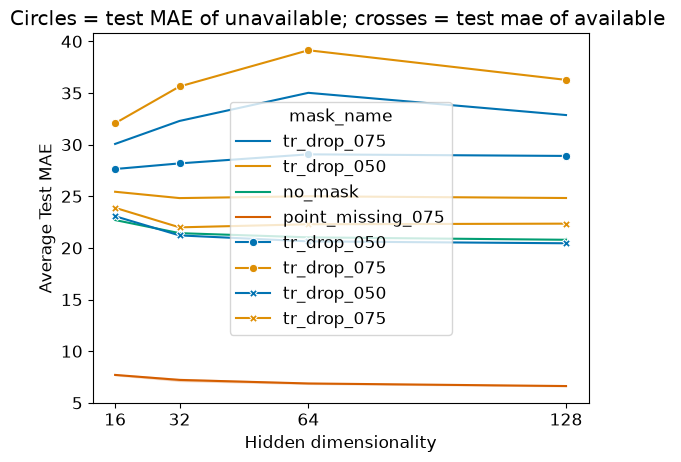

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(runs.set_index('mask_name').loc[["tr_drop_075", "tr_drop_050", 'no_mask', 'point_missing_075'],:].reset_index(), x="n_hid", y="test_avg_mae", hue='mask_name', palette = 'colorblind')
# sns.lineplot(runs, x="n_hid", y="test_avg_mae", hue='mask_name')

sns.lineplot(runs[runs.mask_name.isin(["tr_drop_050", "tr_drop_075"])], x="n_hid", y="test_unavailable_sensors_avg_mae", hue='mask_name', palette='colorblind', marker='o')
sns.lineplot(runs[runs.mask_name.isin(["tr_drop_050", "tr_drop_075"])], x="n_hid", y="test_available_sensors_avg_mae", hue='mask_name', palette='colorblind', marker='X')
    
plt.xticks([16,32,64,128])

plt.title("Circles = test MAE of unavailable; crosses = test mae of available ")

plt.xlabel('Hidden dimensionality')
plt.ylabel('Average Test MAE')

plt.savefig('img/ablation_hidden_dim.png', dpi=300)

/tmp/ipykernel_2778709/165549018.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  l2 = sns.lineplot(
/tmp/ipykernel_2778709/165549018.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  l3 = sns.lineplot(
/tmp/ipykernel_2778709/165549018.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  l2 = sns.lineplot(
/tmp/ipykernel_2778709/165549018.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  l3 = sns.lineplot(
/tmp/ipykernel_2778709/165549018.py:61: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


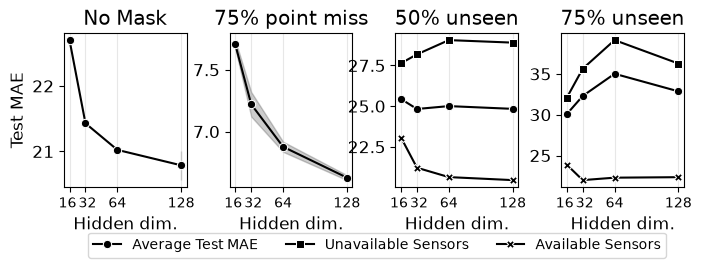

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(8, 2))

# make a gridspec with 2x4
# gs = fig.add_gridspec(2, 4, wspace=0.4)


mask_dictionary = {
    'no_mask': 'No Mask',
    'point_missing_075': '75% point miss',
    'tr_drop_050': '50% unseen',
    'tr_drop_075': '75% unseen',
}

mask_i = 0
for mask in ['no_mask', 'point_missing_075', 'tr_drop_050', 'tr_drop_075']:
    mask_data = runs[runs.mask_name == mask]
    # ax = fig.add_subplot(gs[0, mask_i]) 
    ax = fig.add_subplot(1,4, mask_i + 1)
     
    
    sns.lineplot(
        data=mask_data, x='n_hid', y='test_avg_mae',
        marker='o', ax=ax, legend=mask_i == 3, label='Average Test MAE', color='k'
    )
    
    if 'tr' in mask:
        l2 = sns.lineplot(
            data=mask_data, x='n_hid', y='test_unavailable_sensors_avg_mae',
            palette=['k'],
            marker='s', ax=ax, legend=mask_i == 3, label='Unavailable Sensors', color='k'
        )
        l3 = sns.lineplot(
            data=mask_data, x='n_hid', y='test_available_sensors_avg_mae',
            palette=['k'],
            marker='X', ax=ax, legend=mask_i == 3, label='Available Sensors', color='k'
        )
    
    ax.set_xticks([16, 32, 64, 128])
    ax.set_xticklabels(['16 ', ' 32', '64', '128'], fontsize=10)
    ax.set_title(mask_dictionary[mask])
    
    if mask_i == 0:
        ax.set_ylabel('Test MAE')
    else:
        ax.set_ylabel(None)
    ax.set_xlabel('Hidden dim.')
    ax.grid(axis='x', alpha=0.3)

    if mask_i == 3:
        # handles, labels = ax.get_legend_handles_labels()
        # legend_ax = fig.add_subplot(gs[1, :])
        # legend_ax.legend(handles = [l1,l2,l3])#, ['a', 'b', 'c'], loc='center', ncol=3, fancybox=True, shadow=True)
        # legend_ax.axis('off')
        sns.move_legend(ax, "upper center", bbox_to_anchor=(-1.5, -0.25), ncol=3, fontsize=10, title_fontsize=12)
    
    mask_i += 1
plt.subplots_adjust(wspace=.35)
plt.tight_layout()
plt.savefig('img/ablation_hidden_dim_facet.png', dpi=300, bbox_inches='tight')

## Ablation Repulsion

In [48]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_repulsion_loss_v2"]}}, {'state': 'finished'}]}), access_metadata = False)    

100%|██████████| 30/30 [00:07<00:00,  3.92it/s]


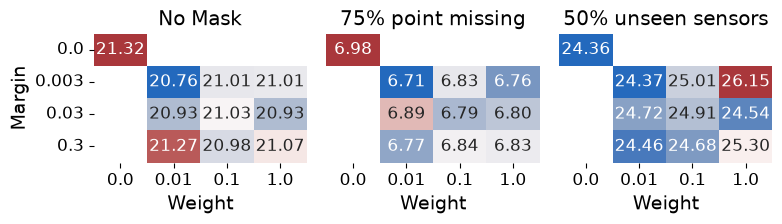

In [49]:
runs.groupby(['mask_name', 'dsn_div_weight', 'dsn_div_margin']).mean(True)

import matplotlib.pyplot as plt 
import seaborn as sns


fig = plt.figure(figsize=(8, 2.4))

mask_dictionary = {
    'no_mask': 'No Mask',
    'point_missing_075': '75% point missing',
    'tr_drop_050': '50% unseen sensors',
    'tr_drop_075': '75% unseen sensors',
}

mask_i = 0

for mask in ['no_mask', 'point_missing_075', 'tr_drop_050']:
    mask_data = runs[runs.mask_name == mask]
    ax = fig.add_subplot(1, 3, mask_i + 1)
    
    sns.heatmap(mask_data.pivot_table(index='dsn_div_margin', columns='dsn_div_weight', values='test_avg_mae'), annot=True, fmt=".2f", cmap='vlag', ax=ax, cbar = mask_i == 3)
    if mask_i == 0:
        ax.set_ylabel('Margin', fontsize=14)
    else:
        ax.set_ylabel(None)
        ax.set_yticks([])
        
    ax.set_xlabel('Weight', fontsize=14)
    
    mask_i += 1
    ax.set_title(mask_dictionary[mask])
    
    ax.tick_params(axis='y', labelrotation=0)
    
plt.tight_layout()
plt.savefig('img/ablation_repulsion_loss.png', dpi=300, bbox_inches='tight')

## Ablation attention method


In [50]:
runs_attention_ablation = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_attention_method"]}}, {'state': 'finished'}]}), access_metadata = False)

100%|██████████| 19/19 [00:04<00:00,  4.08it/s]


In [51]:
runs_attention_ablation = runs_attention_ablation[~runs_attention_ablation.name.str.contains('bias')]
runs_attention_ablation = runs_attention_ablation[~runs_attention_ablation.mask_name.str.contains('tr_drop_075')]

In [52]:
grouped_runs = runs_attention_ablation.groupby(['mask_name', 'attention_method']).mean(True)[['test_avg_mae', 'train_time_per_epoch', 'benchmark_inference_mean_time']]

# calculate for each mask_name how the percentage difference is in the test_avg_mae and benchmark_inference_mean_time is from the MLA to the MHA attention
for mask in grouped_runs.index.get_level_values('mask_name').unique():
    mla_mae = grouped_runs.xs((mask, 'MLA'), level=['mask_name', 'attention_method'])['test_avg_mae'].values[0]
    mha_mae = grouped_runs.xs((mask, 'MHA'), level=['mask_name', 'attention_method'])['test_avg_mae'].values[0]
    mae_diff_percentage = (mha_mae - mla_mae) / mla_mae * 100
    print(f'{mask}: MLA MAE = {mla_mae:.2f}, MHA MAE = {mha_mae:.2f}, Difference = {mae_diff_percentage:.1f}%')
    benchmark_diff_percentage = (grouped_runs.xs((mask, 'MHA'), level=['mask_name', 'attention_method'])['benchmark_inference_mean_time'].values[0] - grouped_runs.xs((mask, 'MLA'), level=['mask_name', 'attention_method'])['benchmark_inference_mean_time'].values[0]) / grouped_runs.xs((mask, 'MLA'), level=['mask_name', 'attention_method'])['benchmark_inference_mean_time'].values[0] * 100
    print(f'{mask}: MLA Inference Time = {grouped_runs.xs((mask, "MLA"), level=["mask_name", "attention_method"])["benchmark_inference_mean_time"].values[0]:.4f}s, MHA Inference Time = {grouped_runs.xs((mask, "MHA"), level=["mask_name", "attention_method"])["benchmark_inference_mean_time"].values[0]:.4f}s, Difference = {benchmark_diff_percentage:.1f}%')

no_mask: MLA MAE = 23.10, MHA MAE = 24.47, Difference = 6.0%
no_mask: MLA Inference Time = 0.0025s, MHA Inference Time = 0.0039s, Difference = 59.5%
point_missing_075: MLA MAE = 7.91, MHA MAE = 8.61, Difference = 8.9%
point_missing_075: MLA Inference Time = 0.0030s, MHA Inference Time = 0.0050s, Difference = 70.3%
tr_drop_050: MLA MAE = 24.89, MHA MAE = 26.84, Difference = 7.8%
tr_drop_050: MLA Inference Time = 0.0025s, MHA Inference Time = 0.0041s, Difference = 64.8%


In [53]:
runs_attention_ablation

,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,static_prefilter_leave_out,gcn_layers,...,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,benchmark_CA,train_mask
0,DSGNN,no_mask,0,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_nomask_2026-05-06 07:42,50,finished,[ablation_attention_method],None,8.521060,False,False,False,False
1,DSGNN,no_mask,0,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_nomask_2026-05-06 07:42,50,finished,[ablation_attention_method],None,9.493412,False,False,False,False
2,DSGNN,tr_drop_050,0,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-05-06 0...,50,finished,[ablation_attention_method],None,5.210208,False,False,False,False
4,DSGNN,tr_drop_050,0,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-05-06 0...,50,finished,[ablation_attention_method],None,5.823555,False,False,False,False
5,DSGNN,point_missing_075,0,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_point_missing_075_0_2026-0...,50,finished,[ablation_attention_method],None,14.506366,False,False,False,False
6,DSGNN,point_missing_075,0,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_point_missing_075_0_2026-0...,50,finished,[ablation_attention_method],None,15.251471,False,False,False,False
8,DSGNN,no_mask,0,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_nomask_attention_MLA_2026-...,50,finished,[ablation_attention_method],None,21.830791,False,False,False,False
9,DSGNN,tr_drop_050,1,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_tr_drop_050_1_attention_ML...,50,finished,[ablation_attention_method],None,10.206650,False,False,False,False
11,DSGNN,point_missing_075,1,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_point_missing_075_1_attent...,25,finished,[ablation_attention_method],None,22.682805,False,False,False,False
13,DSGNN,tr_drop_050,1,SD,None,64,16,static_dsn,None,2,...,DSGNN_SD_2019_DSGNN_tr_drop_050_1_attention_MH...,50,finished,[ablation_attention_method],None,9.121358,False,False,False,False


## GPU Peakmemory

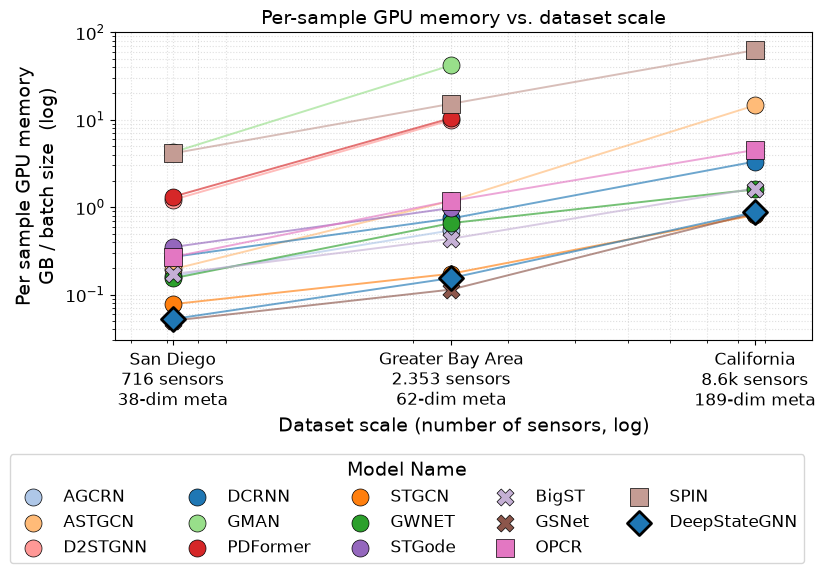

In [54]:
"""
Per-sample GPU training memory vs. dataset scale, for each baseline.

Rationale: almost every model fits batch size 64, so plotting against batch
size piles them onto one tick. Normalising memory by batch size (GB / sample)
spreads them out and turns this into a scaling view:

  - x-axis: dataset scale = number of traffic sensors (log)
  - y-axis: peak training memory PER SAMPLE = GB / batch_size (log)
  - one line per baseline (color), one marker per dataset (shape)
  - lower  = more memory-efficient per sample
  - flatter line = scales better with problem size

Datasets (tuple order left -> right):
  San Diego (SD)          716 sensors,   38-dim metadata
  Greater Bay Area (GBA)  ~2.4k sensors, 62-dim metadata
  California (CA)         8.6k sensors,  189-dim metadata
"""



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 12})

# --- data: baseline -> [(GB, batch_size) for SD, GBA, CA] ------------------
memory_consumption = {
    'AGCRN':    [(10.42, 64), (34.81, 64), (np.nan, np.nan)],
    'ASTGCN':   [(12.45, 64), (75.75, 64), (58.33, 4)],
    'D2STGNN':  [(77.39, 64), (79.44, 8),  (np.nan, np.nan)],
    'DCRNN':    [(17.23, 64), (47.54, 64), (53.16, 16)],
    'GMAN':     [(67.63, 16), (41.98, 1),  (np.nan, np.nan)],
    'PDFormer': [(21.01, 16), (41.74, 4),  (np.nan, np.nan)],
    'STGCN':    [(4.97, 64),  (11.09, 64), (52.04, 64)],
    'GWNET':    [(9.81, 64),  (42.08, 64), (51.12, 32)],
    'STGode':   [(22.35, 64), (62.67, 64), (np.nan, np.nan)],
    'BigST':    [(10.99, 64), (27.87, 64), (52.35, 32)],
    'GSNet':    [(3.22, 64),  (7.31, 64),  (54.63, 64)],
    'OPCR':     [(17.20, 64), (75.49, 64), (72.22, 16)],
    'SPIN':     [(65.92, 16), (60.93, 4),  (125, 2)],
    'DeepStateGNN':    [(3.36, 64),  (9.9, 64),   (56.13, 64)],
}

# --- dataset axis: real scale on x (number of sensors) ---------------------
sensor_counts   = np.array([716, 2352, 8600], dtype=float)   # SD, GBA, CA
dataset_short   = ['SD', 'GBA', 'CA']
dataset_ticklab = ['San Diego\n716 sensors\n38-dim meta',
                   'Greater Bay Area\n2.353 sensors\n62-dim meta',
                   'California\n8.6k sensors\n189-dim meta']
dataset_markers = ['o', 's', '^']

baselines = list(memory_consumption.keys())
# cmap = plt.get_cmap('tab20')
# colors = {name: cmap(i % 20) for i, name in enumerate(baselines)}

fig, ax = plt.subplots(figsize=(9, 4))

for name in baselines:
    gb = np.array([p[0] for p in memory_consumption[name]], dtype=float)
    bs = np.array([p[1] for p in memory_consumption[name]], dtype=float)
    per_sample = gb / bs                      # GB per sample
    valid = ~np.isnan(per_sample)

    ax.plot(sensor_counts[valid], per_sample[valid], '-',
            color=global_color_dict[name], lw=1.4, alpha=0.65, zorder=2)
    for i in np.where(valid)[0]:
        scatter_plot = ax.scatter(sensor_counts[i], per_sample[i],
                   s=150, color=global_color_dict[name], edgecolor='black',
                   linewidth=0.5 if name != 'DeepStateGNN' else 2.0, zorder=3, marker =category_dict[global_category_dict[name]], label= name if i == 0 else None) 
        
ax.get_legend_handles_labels()
# plt.legend(fontsize=14, title='Baseline', bbox_to_anchor=(1.01, 1.0), loc='upper left', ncol=1, title_fontsize=16)
# handles, labels = 
# label_index = labels.index('category')

# # change the shape of the handles to squares
# for i in range(1, label_index):
#     handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
#     handles[i].set_markersize(10)

# plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(-1.4, -.9), loc='lower center', ncol = 7, title_fontsize=16)

#  sns.scatterplot(data=mask_data, x='model_paramters_sd', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax_model_para, legend = mask_i == 3, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
#     sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='model_paramters_sd', y='test_avg_mae', hue='model_name', s=70, ax = ax_model_para, legend = mask_i == 3, edgecolor='black',marker='D', linewidth=2)
    
#     if mask_i == 3:
#         # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
#         handles, labels = ax_model_para.get_legend_handles_labels()
#         label_index = labels.index('category')
        
#         # change the shape of the handles to squares
#         for i in range(1, label_index):
#             handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
#             handles[i].set_markersize(10)
        
#         plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(-1.4, -.9), loc='lower center', ncol = 7, title_fontsize=16)
#     ax_model_para.set_title(None)


# --- axes -------------------------------------------------------------------
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(sensor_counts)
ax.set_xticklabels(dataset_ticklab, fontsize=12)
ax.set_xlim(560, 11000)
ax.set_ylim(0.03, 100)
ax.grid(True, which='both', ls=':', alpha=0.4)

ax.set_xlabel('Dataset scale (number of sensors, log)', fontsize=14)
ax.set_ylabel('Per sample GPU memory\nGB / batch size  (log)', fontsize=14)
ax.set_title('Per-sample GPU memory vs. dataset scale', fontsize=14)

# --- "best area": bottom band = low memory per sample ----------------------
# xmin, xmax = ax.get_xlim()
# ax.axhspan(0.03, 0.3, facecolor='tab:green', alpha=0.10, zorder=0)
# ax.text(600, 0.037, 'efficient region\n(low memory per sample)',
#         fontsize=16, color='tab:green', fontweight='bold', va='bottom')
# ax.annotate('', xy=(650, 0.05), xytext=(650, 1.0),
#             arrowprops=dict(arrowstyle='->', color='tab:green', lw=1.6))

# --- legends: baselines (color) + datasets (marker) ------------------------
# color_handles = [Line2D([0], [0], color=colors[n], lw=2, label=n)
                #  for n in baselines]
# marker_handles = [Line2D([0], [0], marker=m, color='black', lw=0,
#                          markerfacecolor='grey', markersize=9, label=lab)
#                   for m, lab in zip(dataset_markers, dataset_short)]

# leg1 = plt.legend( ax.get_legend_handles_labels()[0], ax.get_legend_handles_labels()[1], title='Baseline',
#                  loc='upper left', bbox_to_anchor=(1.01, 1.0),
#                  fontsize=14, ncol=1)

leg1 = plt.legend(ax.get_legend_handles_labels()[0], ax.get_legend_handles_labels()[1], title='Model Name', bbox_to_anchor=(1, -.75), loc='lower right', ncol = 5, title_fontsize=14)

# ax.add_artist(leg1)
# ax.legend(handles=marker_handles, title='Dataset (marker)',
        #   loc='lower left', bbox_to_anchor=(1.01, 0.0), fontsize=14)

# fig.tight_layout()
fig.savefig('img/gpu_memory_per_sample.png', dpi=150, bbox_inches='tight')
# plt.show()

## Adjacency Matrix

In [55]:
def get_road_mask(file_content, threshold = 0.5):
    street_counts = file_content['static_assignment_matrices'].sum(axis = 0)[file_content['static_assignmnent_dimensions'][()]['road'][0]:file_content['static_assignmnent_dimensions'][()]['road'][1]]
    street_counts_sorted_indices = np.argsort(street_counts)

    index_of_trash = np.argmin(
        np.abs(
            street_counts[street_counts_sorted_indices].cumsum() / street_counts.sum()  - threshold
            )
    )

    mask = np.ones(street_counts.shape[0], dtype = bool)
    mask[street_counts_sorted_indices[:index_of_trash +1]] = False
    
    road_mask = file_content['static_assignment_matrices'][:,file_content['static_assignmnent_dimensions'][()]['road'][0]:file_content['static_assignmnent_dimensions'][()]['road'][1]][:, mask].any(axis = 1)
    
    return road_mask

def get_neighborhood_mask(file_content, threshold = 0.5):
    neighborhood_counts = file_content['static_assignment_matrices'].sum(axis = 0)[:file_content['static_assignmnent_dimensions'][()]['neighborhoods'][1]]
    neighborhood_counts_sorted_indices = np.argsort(neighborhood_counts)

    index_of_trash = np.argmin(
        np.abs(
            neighborhood_counts[neighborhood_counts_sorted_indices].cumsum() / neighborhood_counts.sum()  - threshold
            )
    )

    mask = np.ones(neighborhood_counts.shape[0], dtype = bool)
    mask[neighborhood_counts_sorted_indices[:index_of_trash +1]] = False
    
    neighborhood_mask = file_content['static_assignment_matrices'][:, :file_content['static_assignmnent_dimensions'][()]['neighborhoods'][1]][:, mask].any(axis = 1)
    
    return neighborhood_mask

In [56]:
## get wandb runs with the wandb tag "meaningful_drop"
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["meaningful_drop"]}}, {'state': 'finished'}, {'config.dataset': 'GBA'}]}), access_metadata = False)

100%|██████████| 42/42 [00:10<00:00,  3.97it/s]


/tmp/ipykernel_2778709/3862700075.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['12.5%', '25%', '50%'])
/tmp/ipykernel_2778709/3862700075.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['12.5%', '25%', '50%'])


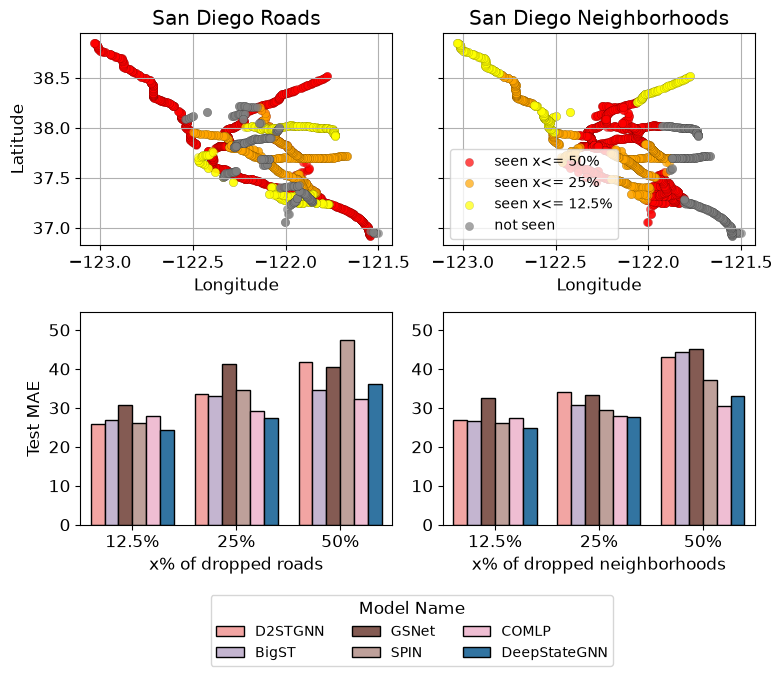

In [57]:
import numpy as np
import pandas as pd
from src.utils.dataloader import get_dataset_info, load_adj_from_numpy
import seaborn as sns
import matplotlib.pyplot as plt

file_content = np.load('data/gba/2019/static_assignment.npz', allow_pickle=True)
meta_data = pd.read_csv('data/gba/gba_meta.csv')


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(2,2, 1)

road_mask_0125 = get_road_mask(file_content, threshold = 0.125)
road_mask_025 = get_road_mask(file_content, threshold = 0.25)
road_mask_050 = get_road_mask(file_content, threshold = 0.50)
### plot the sensors on a map of San Diego, color the sensors by their region, and use the size of the marker to represent the number of lanes
ax.scatter(meta_data['Lng'][road_mask_050], meta_data['Lat'][road_mask_050], alpha=0.7, c = 'red', linewidth = .1, edgecolor = 'black')
ax.scatter(meta_data['Lng'][road_mask_025 & (~road_mask_050)], meta_data['Lat'][road_mask_025 & (~road_mask_050)], alpha=0.7, c = 'orange', linewidth = .1, edgecolor = 'black')
ax.scatter(meta_data['Lng'][road_mask_0125 & (~road_mask_025)], meta_data['Lat'][road_mask_0125 & (~road_mask_025)], alpha=0.7, c = 'yellow', linewidth = .1, edgecolor = 'black')
ax.scatter(meta_data['Lng'][~(road_mask_0125)], meta_data['Lat'][~(road_mask_0125)], alpha=0.7, c = 'gray', linewidth = .1, edgecolor = 'black')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('San Diego Roads')
ax.grid(True)

ax_top_left = ax


ax = fig.add_subplot(2,2, 2)
neighborhood_mask_0125 = get_neighborhood_mask(file_content, threshold = 0.125)
neighborhood_mask_025 = get_neighborhood_mask(file_content, threshold = 0.25)
neighborhood_mask_050 = get_neighborhood_mask(file_content, threshold = 0.50)

ax.scatter(meta_data['Lng'][neighborhood_mask_050], meta_data['Lat'][neighborhood_mask_050], alpha=0.7, c = 'red', label = 'seen x<= 50%', linewidth = .1, edgecolor = 'black')
ax.scatter(meta_data['Lng'][neighborhood_mask_025 & (~neighborhood_mask_050)], meta_data['Lat'][neighborhood_mask_025 & (~neighborhood_mask_050)], alpha=0.7, c = 'orange', label = 'seen x<= 25%', linewidth = .1, edgecolor = 'black')
ax.scatter(meta_data['Lng'][neighborhood_mask_0125 & (~neighborhood_mask_025)], meta_data['Lat'][neighborhood_mask_0125 & (~neighborhood_mask_025)], alpha=0.7, c = 'yellow', label = 'seen x<= 12.5%', linewidth = .1, edgecolor = 'black')
ax.scatter(meta_data['Lng'][~(neighborhood_mask_0125)], meta_data['Lat'][~(neighborhood_mask_0125)], alpha=0.7, c = 'gray', label = 'not seen', linewidth = .1, edgecolor = 'black')

ax.set_xlabel('Longitude')
ax.set_ylabel(None)
ax.set_yticklabels([])
ax.legend(fontsize=10, loc='lower left', title_fontsize=12)

ax.set_title('San Diego Neighborhoods')
ax.grid(True)


##performance 

grouped_road_runs = runs.groupby(['mask_name', 'model_name']).mean(True)
grouped_road_runs = grouped_road_runs.rename(index={'DSGNN': 'DeepStateGNN'})

ax = fig.add_subplot(2,2, 3)

## plot a bar plot with the index mask_name road_drop_025 and road_drop_050 as x-axis and the test_avg_mae as y-axis, with the model_name as hue
sns.barplot(data=grouped_road_runs.reset_index()[grouped_road_runs.reset_index().mask_name.isin(['road_drop_0125', 'road_drop_025', 'road_drop_050'])], x='mask_name', y='test_avg_mae', hue='model_name', ax=ax,  palette=global_color_dict,  edgecolor='black', hue_order =[model for model in global_ordering if model in grouped_road_runs.reset_index().model_name.unique()], legend = False)
ax.set_xlabel('Percentage of dropped neighborhoods')
ax.set_xlabel('x% of dropped roads')
ax.set_ylabel('Test MAE')
ax.set_xticklabels(['12.5%', '25%', '50%'])
ax.set_ylim(0,54.5)

ax_bottom_left = ax
ax = fig.add_subplot(2,2, 4)

## plot a bar plot with the index mask_name neighborhood_drop_025 and neighborhood_drop_050 as x-axis and the test_avg_mae as y-axis, with the model_name as hue
sns.barplot(data=grouped_road_runs.reset_index()[grouped_road_runs.reset_index().mask_name.isin(['neighborhood_drop_0125', 'neighborhood_drop_025', 'neighborhood_drop_050'])], x='mask_name', y='test_avg_mae', hue='model_name', ax=ax, palette=global_color_dict,  edgecolor='black', hue_order =[model for model in global_ordering if model in grouped_road_runs.reset_index().model_name.unique()])
ax.set_xlabel('x% of dropped neighborhoods')
ax.set_ylabel(None)
ax.set_xticklabels(['12.5%', '25%', '50%'])
ax.set_ylim(0,54.5)



fig.tight_layout()

plt.legend(loc='upper center', bbox_to_anchor=(-0.1, -0.3), ncol=3, title='Model Name', fontsize=10, title_fontsize=12)
plt.savefig('img/ablation_road_neighborhood.png', dpi=300, bbox_inches='tight')


"""
Some extra code to generate the masks for the experiments wiht the road or neighborhood dropped masks. 
Has to be moved into the `data/generate_mask_for_experiments.py` file and then run to generate the masks.

"""

import torch
from data.generate_mask_for_experiments import _get_mask
from pathlib import Path
data_path = Path('data/') / 'gba'
ptr = np.load(data_path / '2019' / 'his.npz', allow_pickle=True)
n_samples, n_sensors, _ = ptr['data'].shape
input_mask = _get_mask(n_samples, n_sensors, 0)
output_mask = _get_mask(n_samples, n_sensors, 0)



mask_path = Path('data') / 'masks' / 'gba' / 'neighborhood_drop_0125' / 'mask_00'

mask_path.mkdir(parents=True, exist_ok=True)    

torch.save(input_mask, mask_path / 'input_mask.pt')
torch.save(output_mask, mask_path / 'output_mask.pt')

file_content = np.load('data/gba/2019/static_assignment.npz', allow_pickle=True)

neighborhood_mask = get_neighborhood_mask(file_content, threshold = 0.125)
neighborhood_mask = torch.from_numpy(neighborhood_mask).reshape(1, n_sensors).to(torch.bool)
torch.save(neighborhood_mask, mask_path / 'train_mask.pt')

